# Clustering: A Comprehensive Guide

## 1. Introduction

**Clustering** is an **unsupervised machine learning** technique that groups similar data points together without prior knowledge of group labels. The goal is to partition a dataset into subsets (clusters) such that:
- Points **within** a cluster are as **similar** as possible (high intra-cluster similarity)
- Points **across** clusters are as **dissimilar** as possible (low inter-cluster similarity)

### Why Clustering?
| Use Case | Domain | Example |
| --- | --- | --- |
| Customer Segmentation | Marketing | Group customers by purchasing behavior |
| Anomaly Detection | Cybersecurity | Identify unusual network traffic patterns |
| Document Clustering | NLP | Group news articles by topic |
| Image Segmentation | Computer Vision | Separate foreground from background |
| Gene Expression Analysis | Bioinformatics | Group genes with similar expression patterns |
| Recommendation Systems | E-commerce | Group similar products for recommendations |

### Taxonomy of Clustering Algorithms

```
Clustering Algorithms
├── Partition-based
│   ├── K-Means
│   ├── K-Medoids (PAM)
│   └── K-Modes
├── Hierarchical
│   ├── Agglomerative (bottom-up)
│   └── Divisive (top-down)
├── Density-based
│   ├── DBSCAN
│   ├── OPTICS
│   └── Mean Shift
├── Distribution-based
│   └── Gaussian Mixture Models (GMM)
├── Graph-based
│   └── Spectral Clustering
└── Others
    ├── Affinity Propagation
    └── BIRCH
```

### Distance Metrics (Foundation)

Most clustering algorithms rely on a **distance/similarity metric**:

| Metric | Formula | Best For |
| --- | --- | --- |
| Euclidean | $$d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$ | Continuous, spherical clusters |
| Manhattan | $$d(x,y) = \sum_{i=1}^{n}\lvert x_i - y_i \rvert$$ | High-dimensional, sparse data |
| Cosine | $$d(x,y) = 1 - \frac{x \cdot y}{\|x\|\|y\|}$$ | Text/document similarity |
| Mahalanobis | $$d(x,y) = \sqrt{(x-y)^T S^{-1} (x-y)}$$ | Correlated features |

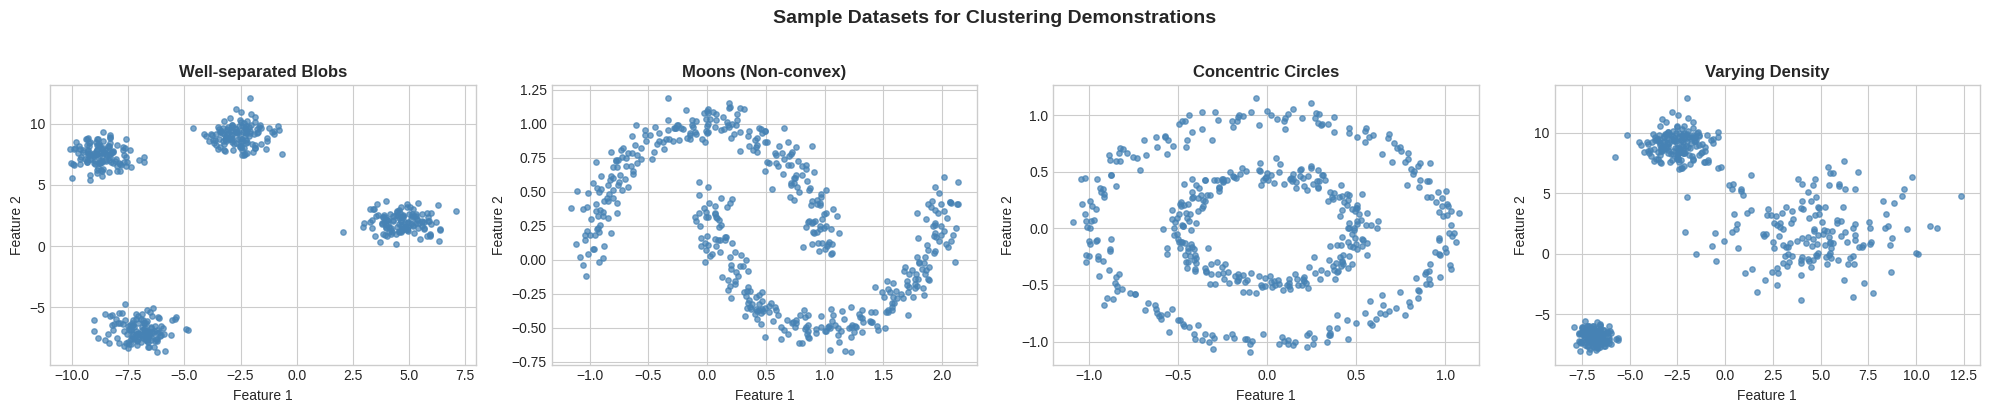

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Generate sample datasets for demonstrations
np.random.seed(42)

# Dataset 1: Well-separated blobs (ideal for K-Means)
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

# Dataset 2: Moons (non-convex shapes)
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=42)

# Dataset 3: Concentric circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# Dataset 4: Varying density clusters
X_varied, y_varied = make_blobs(n_samples=500, cluster_std=[1.0, 2.5, 0.5], centers=3, random_state=42)

# Visualize all datasets
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
datasets = [(X_blobs, 'Well-separated Blobs'), (X_moons, 'Moons (Non-convex)'), 
            (X_circles, 'Concentric Circles'), (X_varied, 'Varying Density')]

for ax, (X, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.7, c='steelblue')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Sample Datasets for Clustering Demonstrations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. K-Means Clustering

### Overview
K-Means is the most popular partition-based clustering algorithm. It partitions $$n$$ observations into $$k$$ clusters where each observation belongs to the cluster with the **nearest centroid**.

### Algorithm (Lloyd's Algorithm)

**Input:** Dataset $$X = \{x_1, x_2, ..., x_n\}$$, number of clusters $$k$$

**Steps:**
1. **Initialize** $$k$$ centroids $$\mu_1, \mu_2, ..., \mu_k$$ randomly from the data points
2. **Assignment Step:** Assign each point $$x_i$$ to the nearest centroid:
$$C_j = \{x_i : \|x_i - \mu_j\|^2 \leq \|x_i - \mu_l\|^2, \forall l \neq j\}$$
3. **Update Step:** Recompute each centroid as the mean of its assigned points:
$$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$
4. **Repeat** steps 2-3 until convergence (centroids no longer change or max iterations reached)

### Objective Function (Inertia / WCSS)

K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

This is an NP-hard optimization problem; Lloyd's algorithm finds a **local minimum**.

### K-Means++ Initialization

Standard random initialization can lead to poor convergence. **K-Means++** provides smarter initialization:

1. Choose first centroid $$\mu_1$$ uniformly at random from $$X$$
2. For each subsequent centroid $$\mu_i$$:
   - Compute distance $$D(x)$$ from each point $$x$$ to the nearest existing centroid
   - Choose next centroid with probability proportional to $$D(x)^2$$
3. Proceed with standard K-Means

This guarantees $$O(\log k)$$-competitive solution.

### Complexity
- **Time:** $$O(n \cdot k \cdot d \cdot i)$$ where $$n$$ = samples, $$k$$ = clusters, $$d$$ = dimensions, $$i$$ = iterations
- **Space:** $$O(n \cdot d + k \cdot d)$$

### Strengths & Weaknesses
| Strengths | Weaknesses |
| --- | --- |
| Simple, fast, scalable | Must specify $$k$$ in advance |
| Guaranteed convergence | Sensitive to initialization |
| Works well with spherical clusters | Assumes spherical, equally-sized clusters |
| Easily parallelizable | Sensitive to outliers |

In [0]:
class KMeansFromScratch:
    """K-Means clustering implemented from scratch."""
    
    def __init__(self, k=3, max_iters=100, tol=1e-4, init='kmeans++', random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.init = init
        self.random_state = random_state
        
    def _initialize_centroids(self, X):
        """Initialize centroids using K-Means++ or random."""
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        if self.init == 'kmeans++':
            # K-Means++ initialization
            centroids = [X[np.random.randint(n_samples)]]
            
            for _ in range(1, self.k):
                # Compute distances to nearest centroid
                distances = np.min([np.sum((X - c)**2, axis=1) for c in centroids], axis=0)
                # Probability proportional to distance squared
                probs = distances / distances.sum()
                # Choose next centroid
                next_centroid_idx = np.random.choice(n_samples, p=probs)
                centroids.append(X[next_centroid_idx])
            
            return np.array(centroids)
        else:
            # Random initialization
            indices = np.random.choice(n_samples, self.k, replace=False)
            return X[indices].copy()
    
    def fit(self, X):
        """Fit K-Means to the data."""
        self.centroids = self._initialize_centroids(X)
        self.history = [self.centroids.copy()]  # Track centroid movement
        
        for iteration in range(self.max_iters):
            # Assignment step: assign each point to nearest centroid
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)
            
            # Update step: recompute centroids
            new_centroids = np.array([
                X[self.labels == j].mean(axis=0) if np.sum(self.labels == j) > 0 
                else self.centroids[j]
                for j in range(self.k)
            ])
            
            self.history.append(new_centroids.copy())
            
            # Check convergence
            centroid_shift = np.sum((new_centroids - self.centroids)**2)
            if centroid_shift < self.tol:
                print(f"Converged after {iteration + 1} iterations")
                break
            
            self.centroids = new_centroids
        
        # Compute inertia (WCSS)
        self.inertia = sum(
            np.sum((X[self.labels == j] - self.centroids[j])**2)
            for j in range(self.k)
        )
        return self
    
    def _compute_distances(self, X):
        """Compute Euclidean distance from each point to each centroid."""
        return np.array([np.sum((X - c)**2, axis=1) for c in self.centroids]).T
    
    def predict(self, X):
        """Predict cluster labels for new data."""
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

# Fit our K-Means implementation
kmeans_scratch = KMeansFromScratch(k=4, random_state=42)
kmeans_scratch.fit(X_blobs)

print(f"Inertia (WCSS): {kmeans_scratch.inertia:.2f}")
print(f"Centroid locations:\n{kmeans_scratch.centroids}")

Converged after 2 iterations
Inertia (WCSS): 607.29
Centroid locations:
[[ 4.70543542  1.93371842]
 [-6.97669736 -6.89958795]
 [-8.71289556  7.42906626]
 [-2.58361185  9.07680526]]


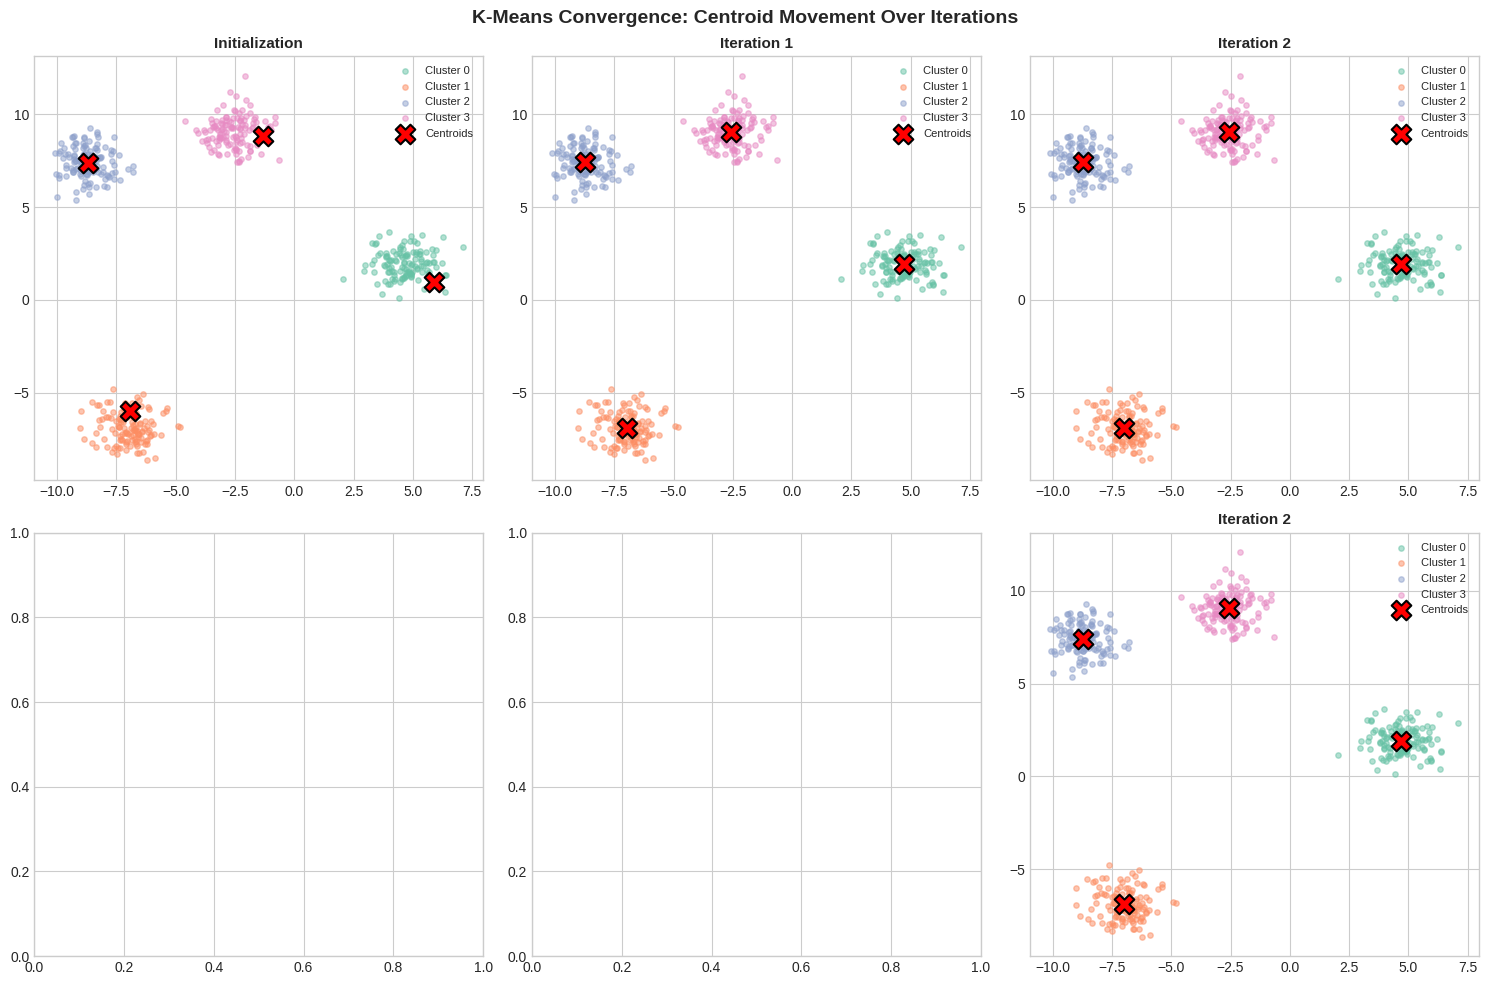

In [0]:
# Visualize K-Means convergence step by step
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
steps_to_show = [0, 1, 2, 3, 5, len(kmeans_scratch.history)-1]

for idx, (ax, step) in enumerate(zip(axes.flatten(), steps_to_show)):
    if step < len(kmeans_scratch.history):
        centroids = kmeans_scratch.history[step]
        # Assign labels based on these centroids
        distances = np.array([np.sum((X_blobs - c)**2, axis=1) for c in centroids]).T
        labels = np.argmin(distances, axis=1)
        
        for j in range(4):
            mask = labels == j
            ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], s=15, alpha=0.5, label=f'Cluster {j}')
        
        ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, 
                   edgecolors='black', linewidths=1.5, zorder=5, label='Centroids')
        
        if step == 0:
            ax.set_title(f'Initialization', fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'Iteration {step}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('K-Means Convergence: Centroid Movement Over Iterations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

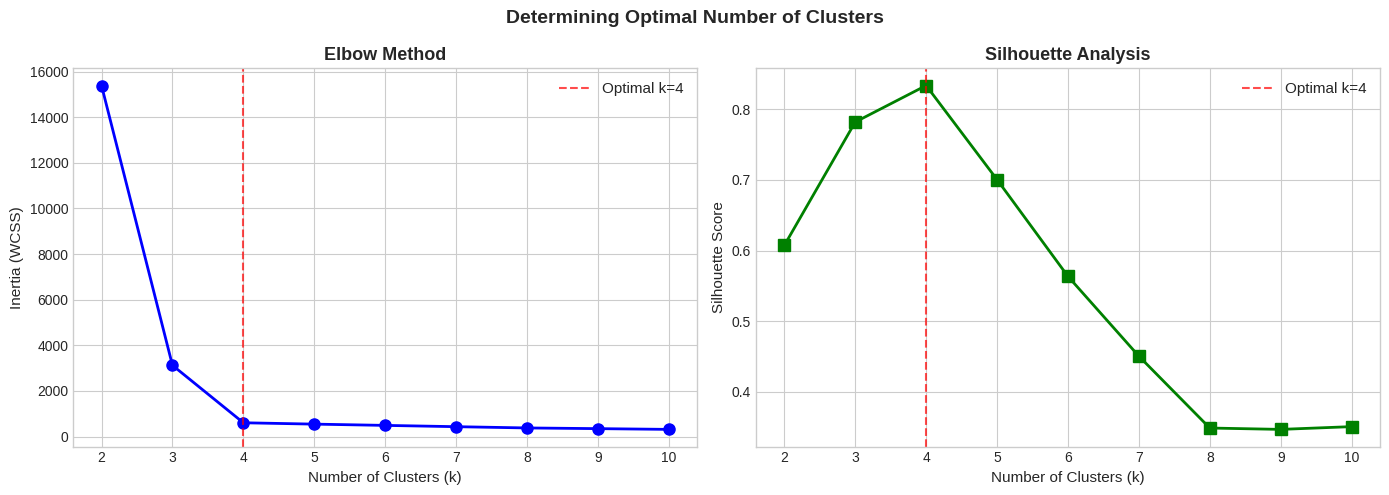


Optimal k by Silhouette Score: 4
Best Silhouette Score: 0.8336


In [0]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Elbow Method + Silhouette Score for optimal k
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_blobs, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)

# Silhouette score plot
ax2.plot(k_range, silhouette_scores, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.suptitle('Determining Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOptimal k by Silhouette Score: {list(k_range)[np.argmax(silhouette_scores)]}")
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")

---
## 3. Hierarchical Clustering

### Overview
Hierarchical clustering builds a **tree of clusters** (dendrogram) without requiring the number of clusters $$k$$ to be specified upfront.

### Types

#### Agglomerative (Bottom-Up) — Most Common
1. Start with each point as its own cluster ($$n$$ clusters)
2. Repeatedly **merge** the two closest clusters
3. Continue until all points form a single cluster
4. Cut the dendrogram at desired level to get $$k$$ clusters

#### Divisive (Top-Down)
1. Start with all points in one cluster
2. Repeatedly **split** the most heterogeneous cluster
3. Continue until each point is its own cluster

### Linkage Criteria (How to measure inter-cluster distance)

Given clusters $$A$$ and $$B$$:

| Linkage | Formula | Characteristics |
| --- | --- | --- |
| **Single** (MIN) | $$d(A,B) = \min_{a \in A, b \in B} d(a,b)$$ | Can handle non-elliptical shapes; prone to chaining |
| **Complete** (MAX) | $$d(A,B) = \max_{a \in A, b \in B} d(a,b)$$ | Produces compact clusters; sensitive to outliers |
| **Average** (UPGMA) | $$d(A,B) = \frac{1}{|A||B|} \sum_{a \in A} \sum_{b \in B} d(a,b)$$ | Compromise between single and complete |
| **Ward's** | $$\Delta(A,B) = \frac{|A||B|}{|A|+|B|} \|\bar{A} - \bar{B}\|^2$$ | Minimizes total within-cluster variance; tends to produce equal-sized clusters |

### Ward's Method (Detailed)

Ward's linkage minimizes the increase in total within-cluster variance when merging:

$$\Delta(A,B) = \text{WCSS}(A \cup B) - \text{WCSS}(A) - \text{WCSS}(B)$$

This is equivalent to:
$$\Delta(A,B) = \frac{n_A \cdot n_B}{n_A + n_B} \|\bar{x}_A - \bar{x}_B\|^2$$

### Complexity
- **Time:** $$O(n^3)$$ naive, $$O(n^2 \log n)$$ with priority queues
- **Space:** $$O(n^2)$$ (distance matrix)

### Strengths & Weaknesses
| Strengths | Weaknesses |
| --- | --- |
| No need to pre-specify $$k$$ | $$O(n^2)$$ space — not scalable for large datasets |
| Dendrogram provides insights | Cannot undo merges (greedy) |
| Different linkages for different shapes | Sensitive to noise/outliers |

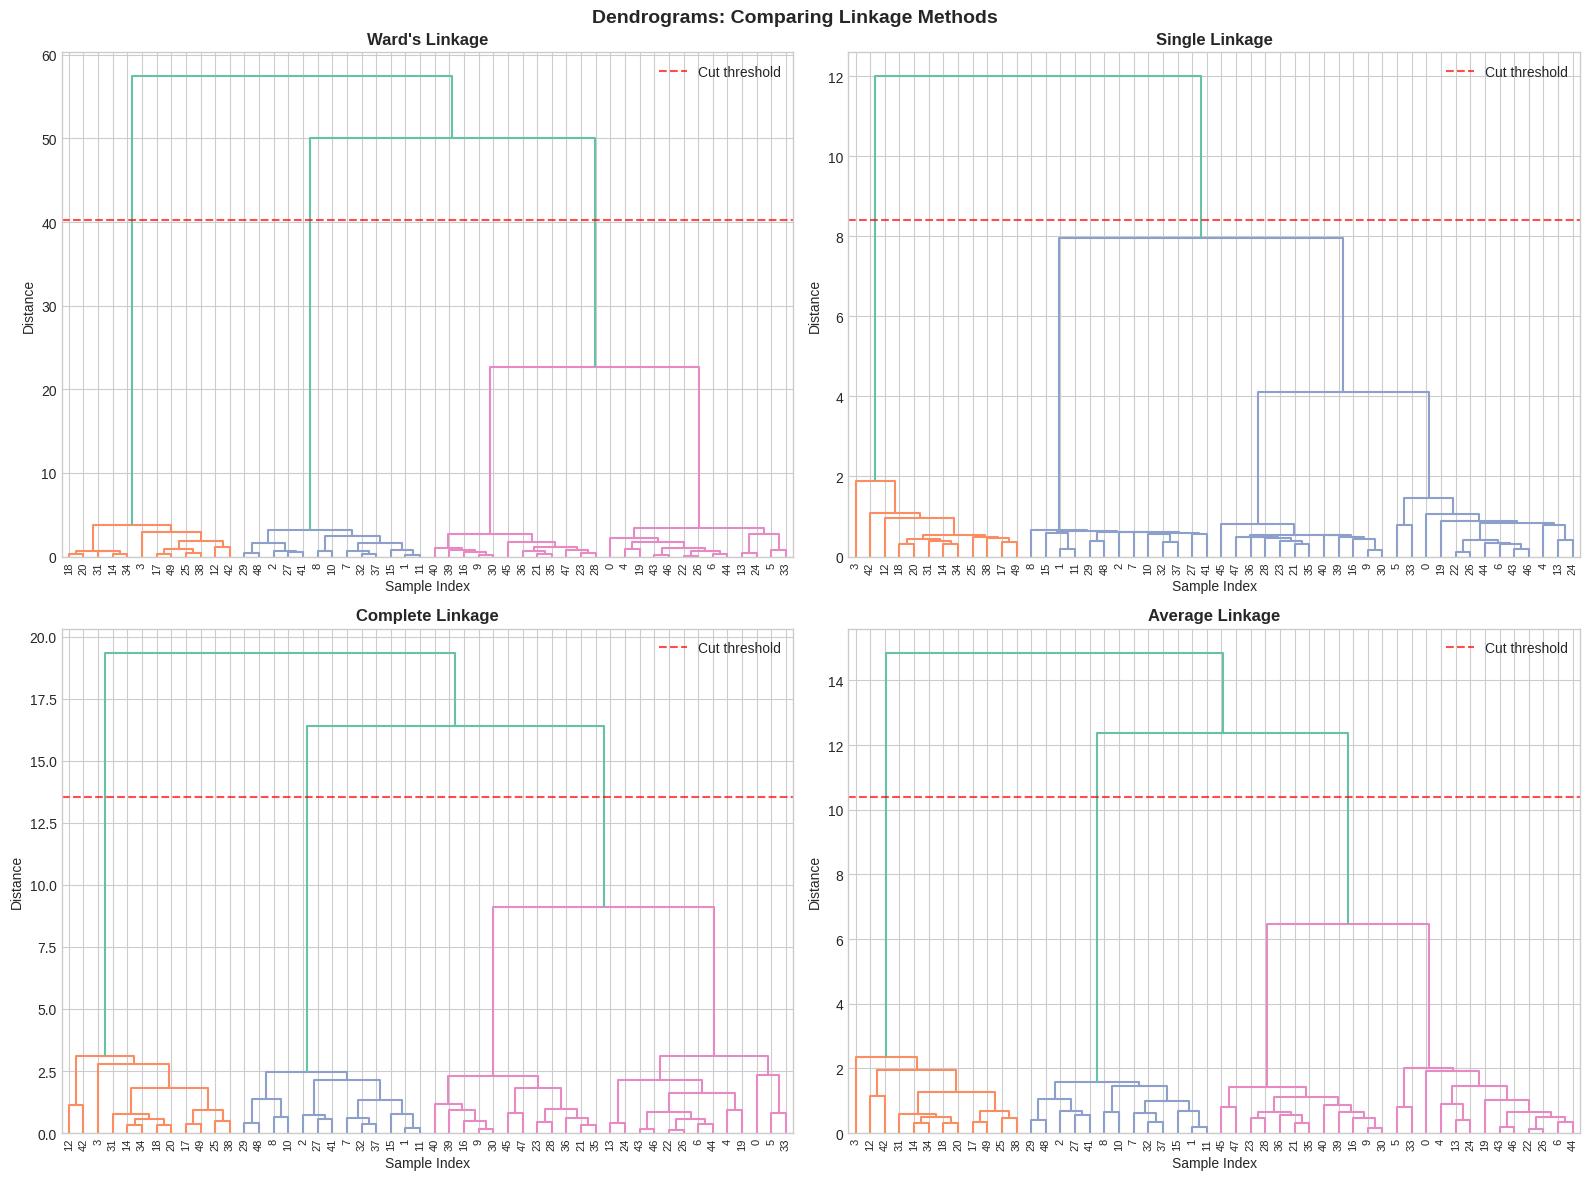

In [0]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# Use a smaller subset for clear dendrogram visualization
np.random.seed(42)
X_small, y_small = make_blobs(n_samples=50, centers=4, cluster_std=0.8, random_state=42)

# Compute linkage matrix using Ward's method
Z_ward = linkage(X_small, method='ward')
Z_single = linkage(X_small, method='single')
Z_complete = linkage(X_small, method='complete')
Z_average = linkage(X_small, method='average')

# Plot dendrograms for different linkages
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
linkages = [(Z_ward, "Ward's Linkage"), (Z_single, 'Single Linkage'),
            (Z_complete, 'Complete Linkage'), (Z_average, 'Average Linkage')]

for ax, (Z, title) in zip(axes.flatten(), linkages):
    dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=8,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Distance')
    ax.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--', alpha=0.7, label='Cut threshold')
    ax.legend()

plt.suptitle('Dendrograms: Comparing Linkage Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

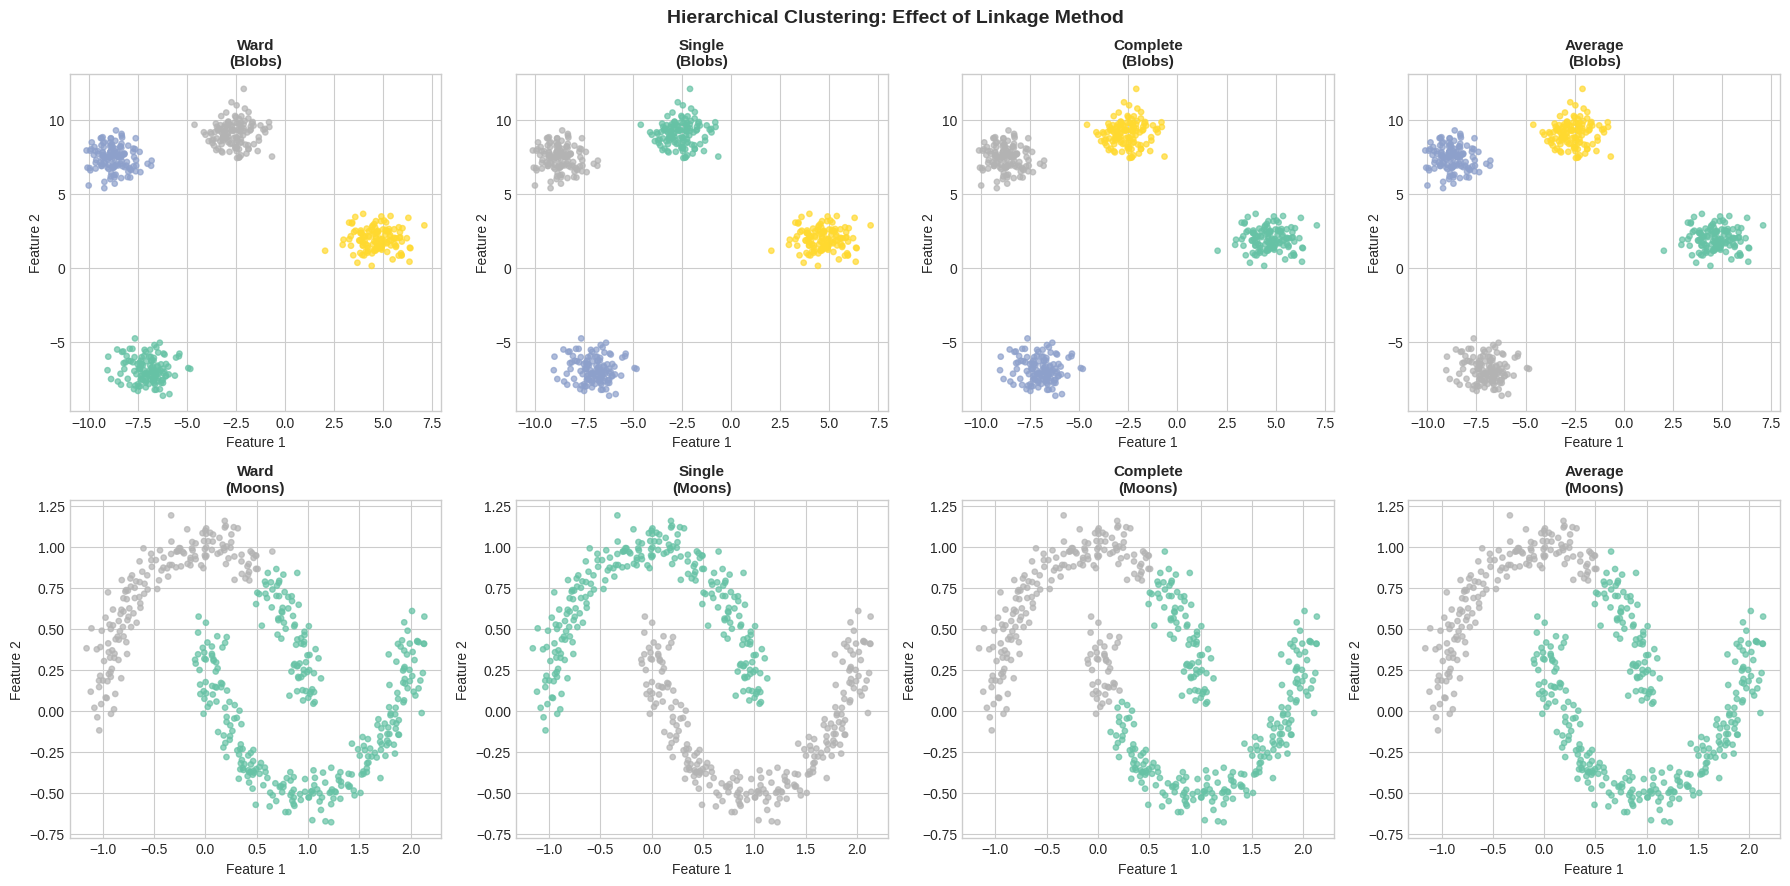


Key Insight: Single linkage handles non-convex shapes (moons) well,
while Ward's linkage works best for compact, spherical clusters.


In [0]:
# Compare linkage methods on different datasets
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

linkage_methods = ['ward', 'single', 'complete', 'average']
datasets_hier = [(X_blobs, 'Blobs'), (X_moons, 'Moons')]

for row, (X, dataset_name) in enumerate(datasets_hier):
    for col, method in enumerate(linkage_methods):
        agg = AgglomerativeClustering(n_clusters=4 if dataset_name == 'Blobs' else 2, 
                                       linkage=method)
        labels = agg.fit_predict(X)
        
        ax = axes[row, col]
        scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set2', s=15, alpha=0.7)
        ax.set_title(f'{method.capitalize()}\n({dataset_name})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')

plt.suptitle('Hierarchical Clustering: Effect of Linkage Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insight: Single linkage handles non-convex shapes (moons) well,")
print("while Ward's linkage works best for compact, spherical clusters.")

---
## 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### Overview
DBSCAN groups together points that are closely packed (dense regions), marking points in low-density regions as **outliers/noise**. Unlike K-Means, it doesn't require specifying $$k$$ and can find **arbitrarily-shaped clusters**.

### Key Concepts

**Parameters:**
- $$\varepsilon$$ (eps): Maximum radius of the neighborhood
- $$\text{MinPts}$$: Minimum number of points required to form a dense region

**Point Classification:**
- **Core Point:** Has at least $$\text{MinPts}$$ points within distance $$\varepsilon$$ (including itself)
$$|N_\varepsilon(p)| \geq \text{MinPts}, \quad \text{where } N_\varepsilon(p) = \{q \in D : d(p,q) \leq \varepsilon\}$$
- **Border Point:** Within $$\varepsilon$$ of a core point but has fewer than $$\text{MinPts}$$ neighbors
- **Noise Point:** Neither core nor border point

**Reachability:**
- **Directly density-reachable:** Point $$q$$ is directly density-reachable from $$p$$ if $$q \in N_\varepsilon(p)$$ and $$p$$ is a core point
- **Density-reachable:** There exists a chain of directly density-reachable points from $$p$$ to $$q$$
- **Density-connected:** Points $$p$$ and $$q$$ are density-connected if there exists a point $$o$$ such that both $$p$$ and $$q$$ are density-reachable from $$o$$

### Algorithm

```
DBSCAN(D, eps, MinPts):
    C = 0  (cluster counter)
    for each unvisited point p in D:
        mark p as visited
        N = getNeighbors(p, eps)
        if |N| < MinPts:
            mark p as NOISE
        else:
            C = C + 1
            expandCluster(p, N, C, eps, MinPts)

expandCluster(p, N, C, eps, MinPts):
    add p to cluster C
    for each point q in N:
        if q is not visited:
            mark q as visited
            N' = getNeighbors(q, eps)
            if |N'| >= MinPts:
                N = N ∪ N'  (expand neighborhood)
        if q is not yet member of any cluster:
            add q to cluster C
```

### Choosing Parameters
- **MinPts:** Rule of thumb: $$\text{MinPts} \geq d + 1$$ where $$d$$ is dimensionality. Common choice: $$2d$$
- **eps:** Use the **k-distance graph** — plot sorted distances to the $$k$$-th nearest neighbor and look for the "elbow"

### Complexity
- **Time:** $$O(n \log n)$$ with spatial indexing (KD-tree/Ball-tree), $$O(n^2)$$ without
- **Space:** $$O(n)$$

### Strengths & Weaknesses
| Strengths | Weaknesses |
| --- | --- |
| No need to specify $$k$$ | Sensitive to $$\varepsilon$$ and MinPts |
| Can find arbitrary-shaped clusters | Struggles with varying density |
| Robust to outliers (marks them as noise) | Not suitable for high-dimensional data |
| Deterministic for core points | Border points can be non-deterministic |

In [0]:
from sklearn.neighbors import NearestNeighbors

class DBSCANFromScratch:
    """DBSCAN implemented from scratch."""
    
    def __init__(self, eps=0.5, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts
        
    def fit(self, X):
        n_samples = X.shape[0]
        self.labels = np.full(n_samples, -1)  # -1 = unvisited/noise
        visited = np.zeros(n_samples, dtype=bool)
        cluster_id = 0
        
        for i in range(n_samples):
            if visited[i]:
                continue
            
            visited[i] = True
            neighbors = self._get_neighbors(X, i)
            
            if len(neighbors) < self.min_pts:
                # Mark as noise (might be relabeled later as border)
                self.labels[i] = -1
            else:
                # Start a new cluster
                self._expand_cluster(X, i, neighbors, cluster_id, visited)
                cluster_id += 1
        
        self.n_clusters = cluster_id
        return self
    
    def _get_neighbors(self, X, point_idx):
        """Find all points within eps distance."""
        distances = np.sqrt(np.sum((X - X[point_idx])**2, axis=1))
        return np.where(distances <= self.eps)[0]
    
    def _expand_cluster(self, X, point_idx, neighbors, cluster_id, visited):
        """Expand cluster from a core point."""
        self.labels[point_idx] = cluster_id
        
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]
            
            if not visited[neighbor_idx]:
                visited[neighbor_idx] = True
                new_neighbors = self._get_neighbors(X, neighbor_idx)
                
                if len(new_neighbors) >= self.min_pts:
                    # This is also a core point - expand
                    neighbors = np.concatenate([neighbors, new_neighbors])
                    neighbors = np.unique(neighbors)
            
            if self.labels[neighbor_idx] == -1:
                self.labels[neighbor_idx] = cluster_id
            
            i += 1

# Apply DBSCAN to moons dataset
dbscan_scratch = DBSCANFromScratch(eps=0.2, min_pts=5)
dbscan_scratch.fit(X_moons)

print(f"Number of clusters found: {dbscan_scratch.n_clusters}")
print(f"Number of noise points: {np.sum(dbscan_scratch.labels == -1)}")
print(f"Cluster sizes: {[np.sum(dbscan_scratch.labels == i) for i in range(dbscan_scratch.n_clusters)]}")

Number of clusters found: 22
Number of noise points: 1
Cluster sizes: [np.int64(160), np.int64(141), np.int64(16), np.int64(27), np.int64(2), np.int64(1), np.int64(1), np.int64(3), np.int64(33), np.int64(12), np.int64(42), np.int64(4), np.int64(3), np.int64(12), np.int64(2), np.int64(5), np.int64(19), np.int64(1), np.int64(4), np.int64(1), np.int64(1), np.int64(9)]


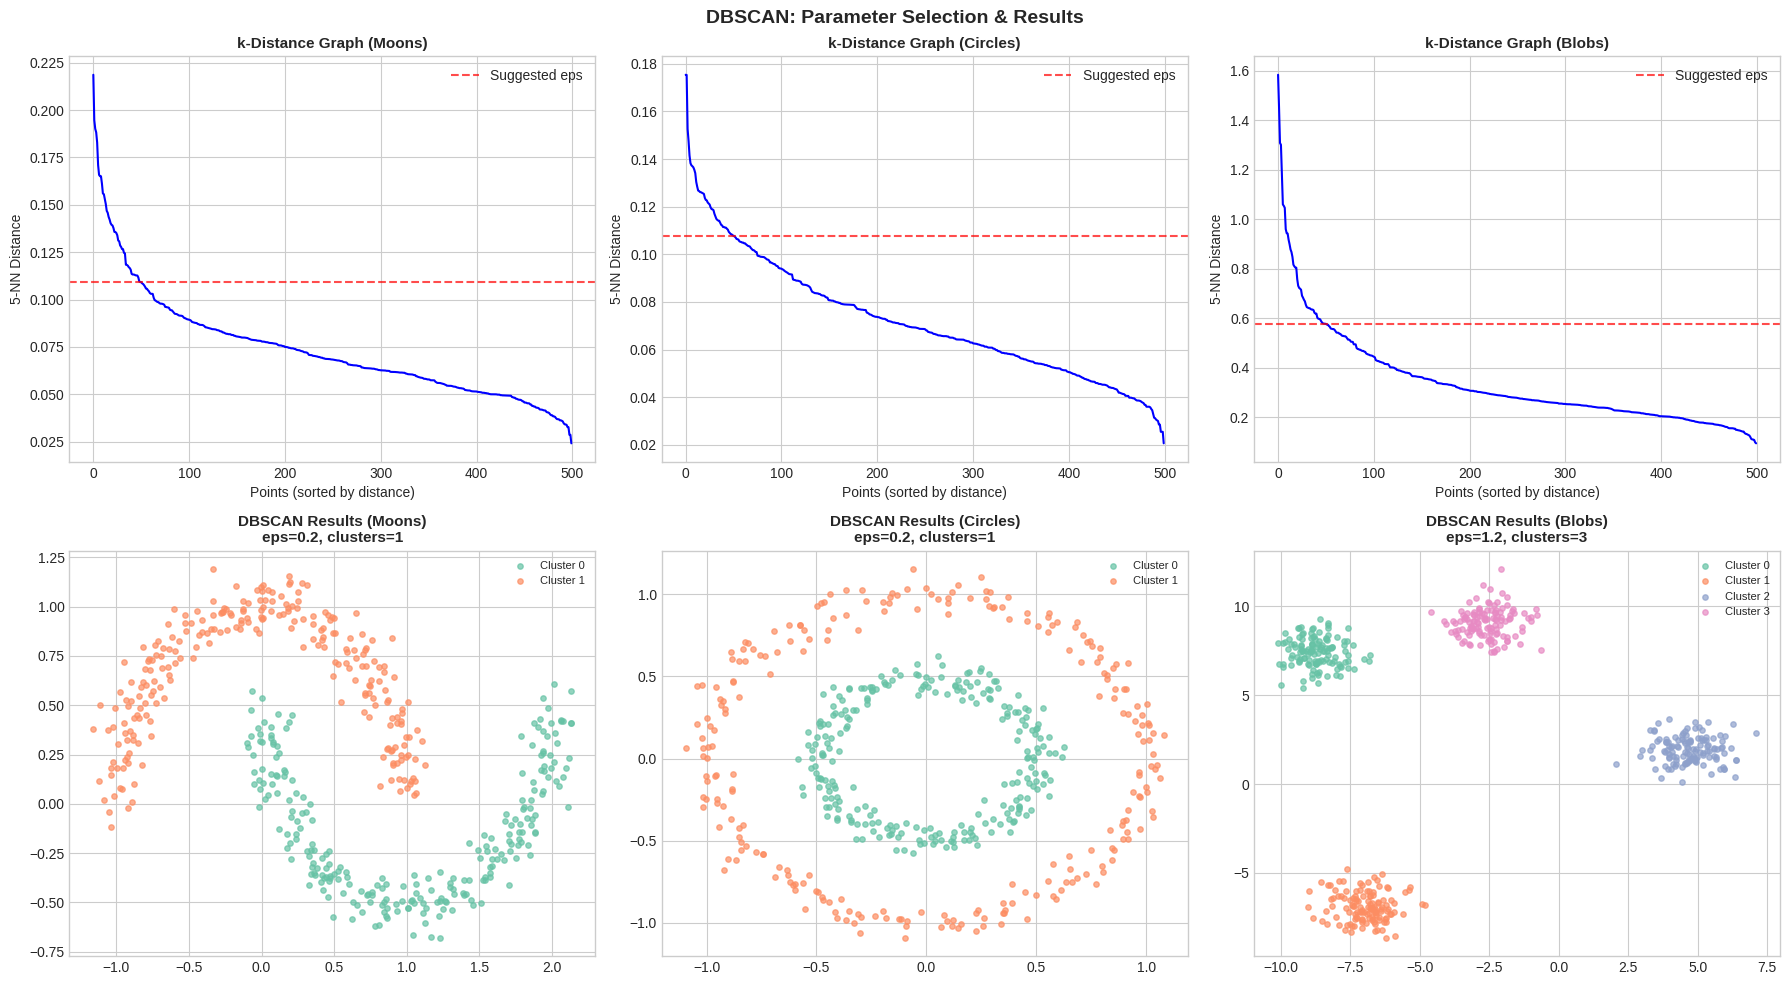

In [0]:
from sklearn.cluster import DBSCAN

# k-Distance graph to find optimal eps
def plot_k_distance(X, k=5):
    """Plot k-distance graph for eps selection."""
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    k_distances = np.sort(distances[:, k-1])[::-1]
    return k_distances

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: k-distance graphs
for idx, (X, name) in enumerate([(X_moons, 'Moons'), (X_circles, 'Circles'), (X_blobs, 'Blobs')]):
    k_dist = plot_k_distance(X, k=5)
    axes[0, idx].plot(range(len(k_dist)), k_dist, 'b-', linewidth=1.5)
    axes[0, idx].set_title(f'k-Distance Graph ({name})', fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel('Points (sorted by distance)')
    axes[0, idx].set_ylabel('5-NN Distance')
    axes[0, idx].axhline(y=np.percentile(k_dist, 90), color='red', linestyle='--', 
                         alpha=0.7, label=f'Suggested eps')
    axes[0, idx].legend()

# Bottom row: DBSCAN results with chosen eps
eps_values = [0.2, 0.2, 1.2]
for idx, (X, name, eps) in enumerate([(X_moons, 'Moons', 0.2), 
                                       (X_circles, 'Circles', 0.2), 
                                       (X_blobs, 'Blobs', 1.2)]):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)
    
    # Plot with noise highlighted
    unique_labels = set(labels)
    for label in unique_labels:
        mask = labels == label
        if label == -1:
            axes[1, idx].scatter(X[mask, 0], X[mask, 1], c='black', s=10, 
                               alpha=0.3, marker='x', label='Noise')
        else:
            axes[1, idx].scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, 
                               label=f'Cluster {label}')
    
    axes[1, idx].set_title(f'DBSCAN Results ({name})\neps={eps}, clusters={len(unique_labels)-1}', 
                           fontsize=11, fontweight='bold')
    axes[1, idx].legend(fontsize=8)

plt.suptitle('DBSCAN: Parameter Selection & Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Gaussian Mixture Models (GMM)

### Overview
GMM is a **probabilistic (soft) clustering** model that assumes data is generated from a mixture of $$k$$ Gaussian distributions. Unlike K-Means (hard assignment), GMM provides **probability of membership** for each cluster.

### Mathematical Formulation

The probability density of the mixture model:
$$p(x) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x | \mu_k, \Sigma_k)$$

where:
- $$\pi_k$$ = mixing coefficient (prior probability of cluster $$k$$), $$\sum_k \pi_k = 1$$
- $$\mathcal{N}(x | \mu_k, \Sigma_k)$$ = multivariate Gaussian:
$$\mathcal{N}(x | \mu, \Sigma) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)$$

### Expectation-Maximization (EM) Algorithm

GMM parameters are estimated using the **EM algorithm**:

#### E-Step (Expectation):
Compute **responsibilities** (posterior probability that point $$x_i$$ belongs to cluster $$k$$):
$$\gamma(z_{ik}) = \frac{\pi_k \cdot \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \cdot \mathcal{N}(x_i | \mu_j, \Sigma_j)}$$

#### M-Step (Maximization):
Update parameters using the responsibilities:

$$N_k = \sum_{i=1}^{n} \gamma(z_{ik})$$

$$\mu_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^{n} \gamma(z_{ik}) \cdot x_i$$

$$\Sigma_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^{n} \gamma(z_{ik}) (x_i - \mu_k^{\text{new}})(x_i - \mu_k^{\text{new}})^T$$

$$\pi_k^{\text{new}} = \frac{N_k}{n}$$

#### Log-Likelihood (Objective):
$$\ln p(X|\pi, \mu, \Sigma) = \sum_{i=1}^{n} \ln \left( \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x_i | \mu_k, \Sigma_k) \right)$$

EM iterates until log-likelihood converges.

### Covariance Types
| Type | Parameters | Shape |
| --- | --- | --- |
| **Full** | $$k \cdot d(d+1)/2$$ | Arbitrary ellipsoid |
| **Tied** | $$d(d+1)/2$$ | Same shape, different location |
| **Diagonal** | $$k \cdot d$$ | Axis-aligned ellipsoid |
| **Spherical** | $$k$$ | Sphere (equivalent to K-Means) |

### Model Selection: BIC and AIC
$$\text{BIC} = -2 \ln L + p \ln n$$
$$\text{AIC} = -2 \ln L + 2p$$

where $$p$$ = number of free parameters, $$n$$ = number of samples. **Lower is better.**

### Strengths & Weaknesses
| Strengths | Weaknesses |
| --- | --- |
| Soft assignments (probabilities) | Assumes Gaussian distribution |
| Can model elliptical clusters | Sensitive to initialization |
| Handles different cluster shapes/sizes | Computationally expensive (full covariance) |
| Principled model selection (BIC/AIC) | Can converge to singular solutions |

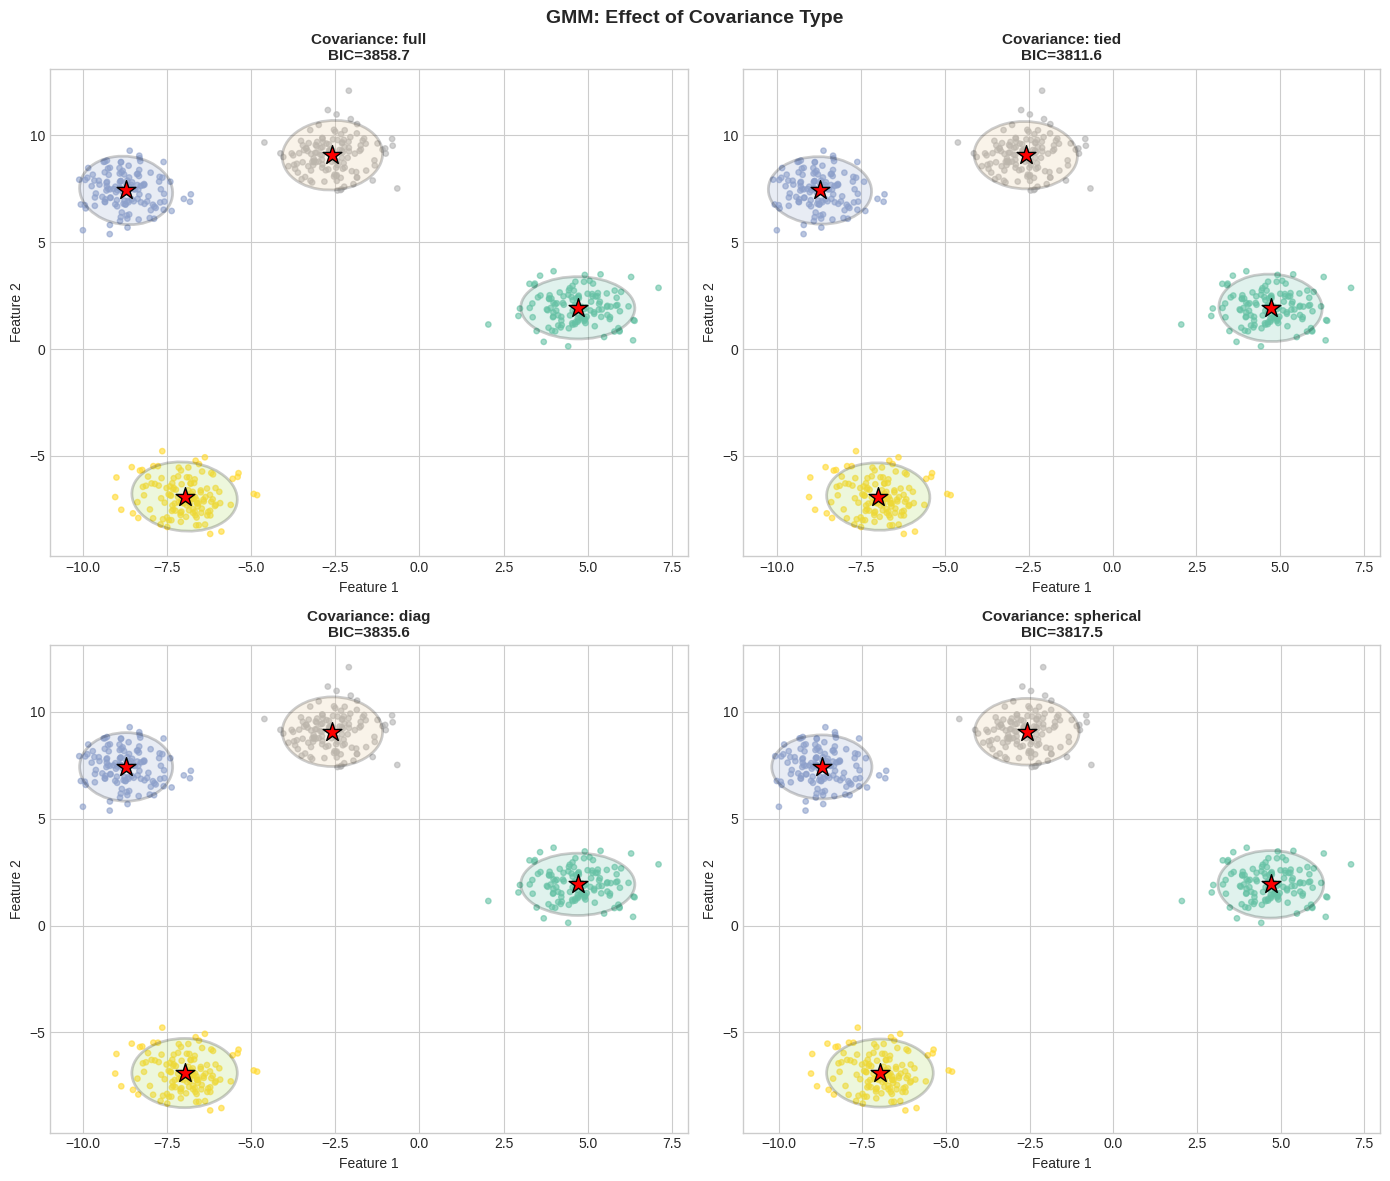

In [0]:
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax, n_std=2.0, **kwargs):
    """Draw an ellipse representing a Gaussian component."""
    if covariance.ndim == 1:
        covariance = np.diag(covariance)
    
    # Eigenvalue decomposition for ellipse orientation
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(xy=position, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Fit GMM with different covariance types
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cov_types = ['full', 'tied', 'diag', 'spherical']

for ax, cov_type in zip(axes.flatten(), cov_types):
    gmm = GaussianMixture(n_components=4, covariance_type=cov_type, random_state=42)
    gmm.fit(X_blobs)
    labels = gmm.predict(X_blobs)
    probs = gmm.predict_proba(X_blobs)
    
    # Plot points colored by cluster
    scatter = ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels, cmap='Set2', 
                         s=15, alpha=0.6)
    
    # Draw Gaussian ellipses
    for i in range(4):
        if cov_type == 'full':
            cov = gmm.covariances_[i]
        elif cov_type == 'tied':
            cov = gmm.covariances_
        elif cov_type == 'diag':
            cov = np.diag(gmm.covariances_[i])
        else:  # spherical
            cov = np.eye(2) * gmm.covariances_[i]
        
        draw_ellipse(gmm.means_[i], cov, ax, alpha=0.2, 
                     facecolor=plt.cm.Set2(i/4), edgecolor='black', linewidth=2)
    
    # Mark means
    ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', marker='*', 
              s=200, edgecolors='black', linewidths=1, zorder=5)
    
    ax.set_title(f'Covariance: {cov_type}\nBIC={gmm.bic(X_blobs):.1f}', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('GMM: Effect of Covariance Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

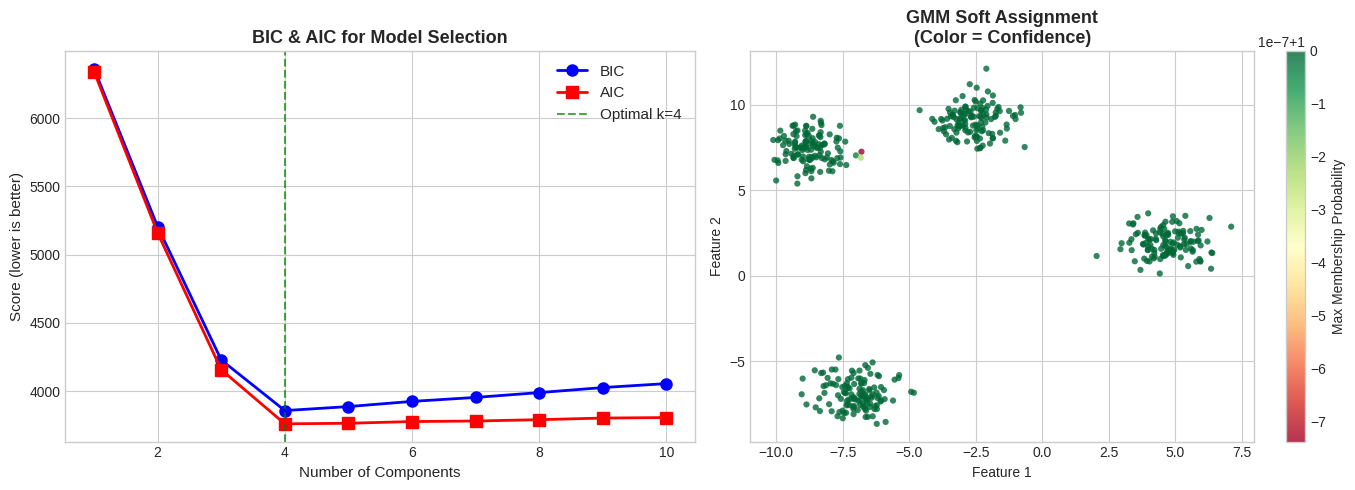


Optimal components by BIC: 4
Optimal components by AIC: 4

Sample membership probabilities (first 5 points):
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]


In [0]:
# Model selection: finding optimal number of components
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_blobs)
    bic_scores.append(gmm.bic(X_blobs))
    aic_scores.append(gmm.aic(X_blobs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BIC/AIC plot
ax1.plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8, label='BIC')
ax1.plot(n_components_range, aic_scores, 'rs-', linewidth=2, markersize=8, label='AIC')
ax1.axvline(x=4, color='green', linestyle='--', alpha=0.7, label='Optimal k=4')
ax1.set_xlabel('Number of Components', fontsize=11)
ax1.set_ylabel('Score (lower is better)', fontsize=11)
ax1.set_title('BIC & AIC for Model Selection', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)

# Soft assignment visualization
gmm_opt = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_opt.fit(X_blobs)
probs = gmm_opt.predict_proba(X_blobs)

# Show uncertainty: points with low max probability are uncertain
max_probs = np.max(probs, axis=1)
labels = gmm_opt.predict(X_blobs)

scatter = ax2.scatter(X_blobs[:, 0], X_blobs[:, 1], c=max_probs, cmap='RdYlGn', 
                      s=20, alpha=0.8, edgecolors='none')
plt.colorbar(scatter, ax=ax2, label='Max Membership Probability')
ax2.set_title('GMM Soft Assignment\n(Color = Confidence)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print(f"\nOptimal components by BIC: {list(n_components_range)[np.argmin(bic_scores)]}")
print(f"Optimal components by AIC: {list(n_components_range)[np.argmin(aic_scores)]}")
print(f"\nSample membership probabilities (first 5 points):")
print(probs[:5].round(3))

---
## 6. Mean Shift Clustering

### Overview
Mean Shift is a **non-parametric, density-based** algorithm that finds cluster centers by iteratively shifting points toward regions of highest density. It doesn't require specifying the number of clusters.

### Mathematical Foundation

#### Kernel Density Estimation (KDE)
Mean Shift is based on estimating the probability density function:
$$\hat{f}(x) = \frac{1}{nh^d} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

where $$K$$ is a kernel function (usually Gaussian) and $$h$$ is the bandwidth.

#### The Mean Shift Vector
The gradient of the density estimate points toward the mode (peak):
$$m(x) = \frac{\sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right) \cdot x_i}{\sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)} - x$$

For a **flat kernel** (uniform within bandwidth $$h$$):
$$m(x) = \frac{\sum_{x_i \in N_h(x)} x_i}{|N_h(x)|} - x$$

This is simply the difference between the mean of points within the bandwidth and the current position.

### Algorithm
1. For each data point $$x_i$$, compute the mean shift vector $$m(x_i)$$
2. Move $$x_i$$ in the direction of $$m(x_i)$$: $$x_i \leftarrow x_i + m(x_i)$$
3. Repeat until convergence (all points reach density peaks)
4. Points that converge to the same peak belong to the same cluster

### Bandwidth Selection
- Too small $$\to$$ too many clusters (overfitting)
- Too large $$\to$$ too few clusters (underfitting)
- **Silverman's rule of thumb:** $$h = \left(\frac{4\sigma^5}{3n}\right)^{1/5}$$
- `sklearn` provides `estimate_bandwidth()` utility

### Complexity
- **Time:** $$O(n^2 \cdot T)$$ where $$T$$ = iterations to convergence
- **Space:** $$O(n)$$

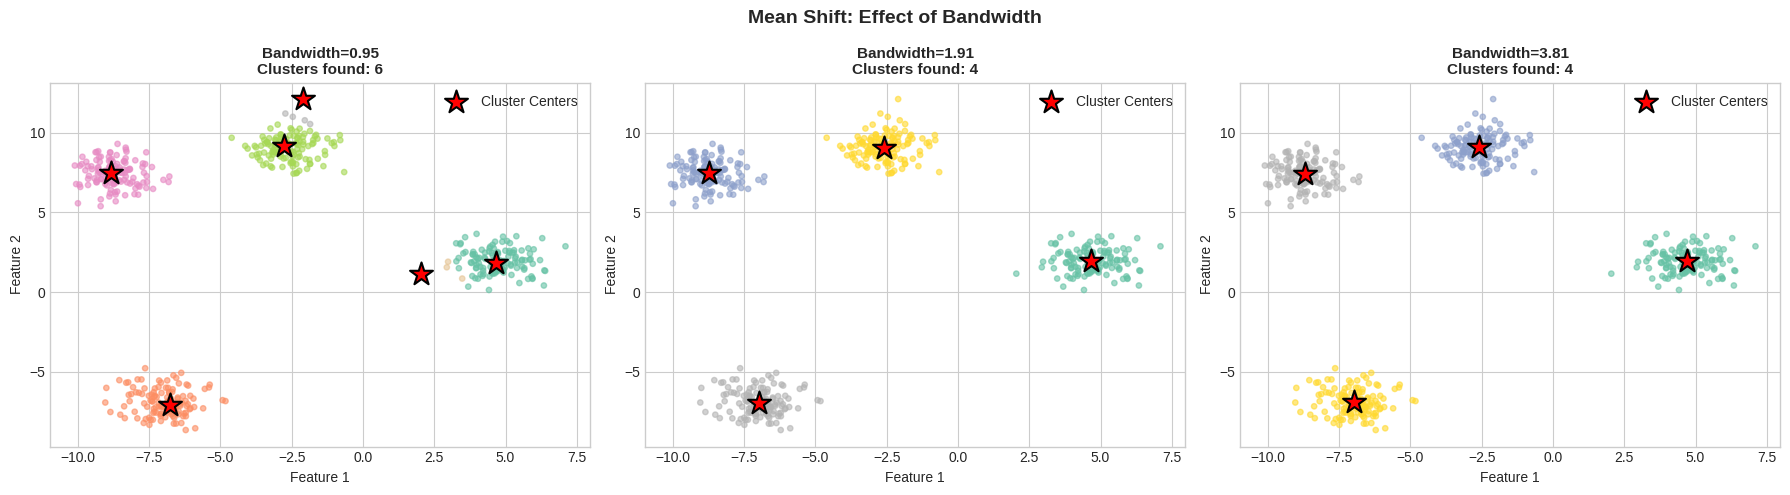

Estimated optimal bandwidth: 1.907
Number of clusters found: 4


In [0]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Estimate bandwidth automatically
bandwidth = estimate_bandwidth(X_blobs, quantile=0.2, n_samples=500)

# Fit Mean Shift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_blobs)
labels_ms = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters_ms = len(np.unique(labels_ms))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Different bandwidth values
bandwidths = [bandwidth * 0.5, bandwidth, bandwidth * 2]
for ax, bw in zip(axes, bandwidths):
    ms_temp = MeanShift(bandwidth=bw, bin_seeding=True)
    ms_temp.fit(X_blobs)
    labels_temp = ms_temp.labels_
    centers_temp = ms_temp.cluster_centers_
    
    n_c = len(np.unique(labels_temp))
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_temp, cmap='Set2', s=15, alpha=0.6)
    ax.scatter(centers_temp[:, 0], centers_temp[:, 1], c='red', marker='*', 
              s=300, edgecolors='black', linewidths=1.5, zorder=5, label='Cluster Centers')
    ax.set_title(f'Bandwidth={bw:.2f}\nClusters found: {n_c}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Mean Shift: Effect of Bandwidth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Estimated optimal bandwidth: {bandwidth:.3f}")
print(f"Number of clusters found: {n_clusters_ms}")

---
## 7. Spectral Clustering

### Overview
Spectral Clustering uses the **eigenvalues (spectrum) of a similarity matrix** to perform dimensionality reduction before clustering in a lower-dimensional space. It excels at finding **non-convex clusters**.

### Mathematical Foundation

#### Step 1: Construct Similarity Graph
Build an affinity matrix $$W$$ (similarity between all pairs of points):
- **RBF (Gaussian) kernel:** $$W_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$$
- **k-nearest neighbors:** $$W_{ij} = 1$$ if $$x_j$$ is among $$k$$-NN of $$x_i$$

#### Step 2: Compute Graph Laplacian
- **Degree matrix:** $$D_{ii} = \sum_j W_{ij}$$
- **Unnormalized Laplacian:** $$L = D - W$$
- **Normalized Laplacian (symmetric):** $$L_{sym} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} W D^{-1/2}$$
- **Normalized Laplacian (random walk):** $$L_{rw} = D^{-1} L = I - D^{-1} W$$

#### Step 3: Eigendecomposition
Compute the first $$k$$ eigenvectors $$u_1, u_2, ..., u_k$$ of $$L$$ (corresponding to the $$k$$ smallest eigenvalues).

Form matrix $$U \in \mathbb{R}^{n \times k}$$ with these eigenvectors as columns.

#### Step 4: Cluster in Spectral Space
Apply K-Means to the rows of $$U$$ (each row is the spectral embedding of a data point).

### Why It Works (Intuition)
- The Laplacian matrix encodes the graph structure
- Small eigenvalues of $$L$$ correspond to "smooth" eigenvectors that are approximately constant within clusters
- The number of zero eigenvalues = number of connected components in the graph
- The eigengap (largest jump between consecutive eigenvalues) suggests optimal $$k$$

### Graph Cut Interpretation
Spectral clustering approximately solves the **Normalized Cut** problem:
$$\text{NCut}(A, B) = \frac{\text{cut}(A,B)}{\text{vol}(A)} + \frac{\text{cut}(A,B)}{\text{vol}(B)}$$

where $$\text{cut}(A,B) = \sum_{i \in A, j \in B} W_{ij}$$ and $$\text{vol}(A) = \sum_{i \in A} d_i$$

### Complexity
- **Time:** $$O(n^3)$$ for eigendecomposition (can be reduced with sparse methods)
- **Space:** $$O(n^2)$$ for affinity matrix

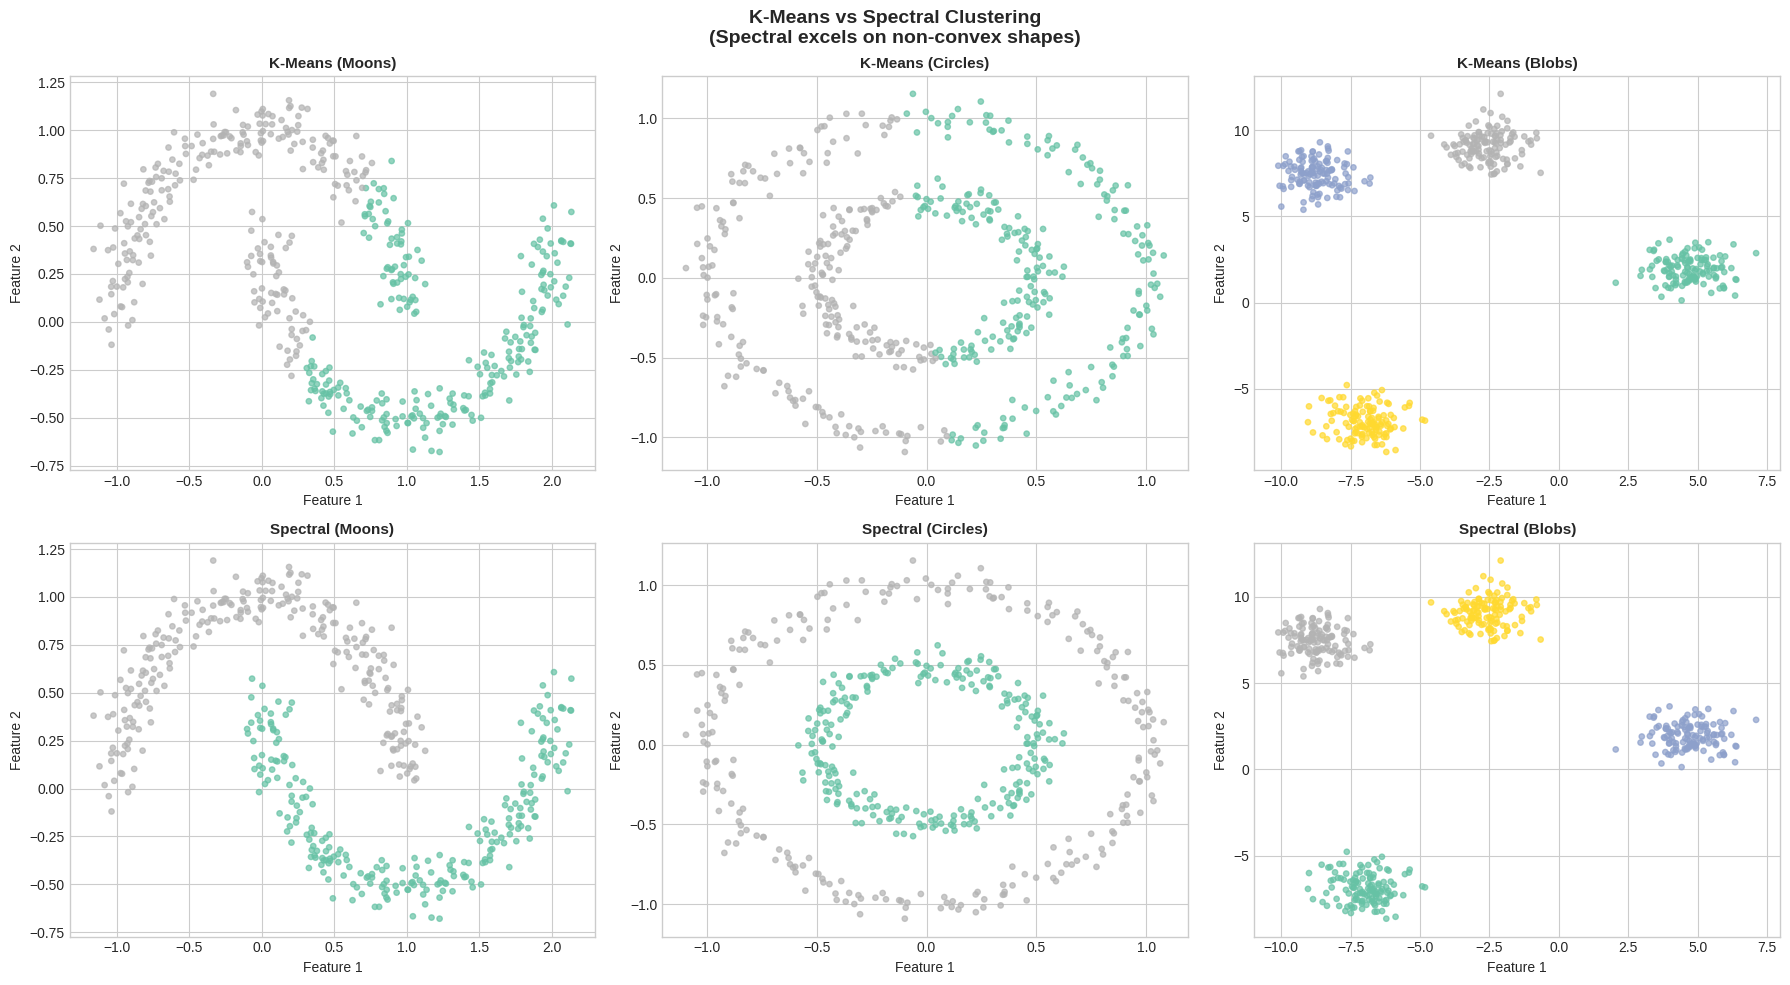

Key Insight: Spectral Clustering correctly separates moons and circles
because it operates on a graph structure rather than Euclidean distances.


In [0]:
from sklearn.cluster import SpectralClustering

# Compare K-Means vs Spectral on non-convex data
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets_spectral = [
    (X_moons, 2, 'Moons'),
    (X_circles, 2, 'Circles'),
    (X_blobs, 4, 'Blobs')
]

for col, (X, n_c, name) in enumerate(datasets_spectral):
    # K-Means
    km = KMeans(n_clusters=n_c, random_state=42, n_init=10)
    labels_km = km.fit_predict(X)
    axes[0, col].scatter(X[:, 0], X[:, 1], c=labels_km, cmap='Set2', s=15, alpha=0.7)
    axes[0, col].set_title(f'K-Means ({name})', fontsize=11, fontweight='bold')
    
    # Spectral Clustering
    sc = SpectralClustering(n_clusters=n_c, affinity='nearest_neighbors', 
                            n_neighbors=10, random_state=42)
    labels_sc = sc.fit_predict(X)
    axes[1, col].scatter(X[:, 0], X[:, 1], c=labels_sc, cmap='Set2', s=15, alpha=0.7)
    axes[1, col].set_title(f'Spectral ({name})', fontsize=11, fontweight='bold')

for ax in axes.flatten():
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('K-Means vs Spectral Clustering\n(Spectral excels on non-convex shapes)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Insight: Spectral Clustering correctly separates moons and circles")
print("because it operates on a graph structure rather than Euclidean distances.")

---
## 8. Cluster Evaluation Metrics

### The Challenge
Evaluating clustering quality is inherently difficult because there's no ground truth in unsupervised learning. We use two categories of metrics:

### A. Internal Metrics (No ground truth needed)
Evaluate cluster quality based on the data alone.

#### 1. Silhouette Score
Measures how similar a point is to its own cluster vs. neighboring clusters.

For each point $$i$$:
- $$a(i)$$ = average distance to all other points in the same cluster (cohesion)
- $$b(i)$$ = average distance to points in the nearest neighboring cluster (separation)

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

**Range:** $$[-1, 1]$$. Higher is better.
- $$s \approx 1$$: Point is well-clustered
- $$s \approx 0$$: Point is on cluster boundary
- $$s < 0$$: Point may be in wrong cluster

#### 2. Davies-Bouldin Index (DBI)
Measures average similarity between each cluster and its most similar cluster.

$$\text{DBI} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(\mu_i, \mu_j)} \right)$$

where $$\sigma_i$$ = average distance of points in cluster $$i$$ to centroid $$\mu_i$$

**Range:** $$[0, \infty)$$. **Lower is better.** Zero means perfect clustering.

#### 3. Calinski-Harabasz Index (Variance Ratio Criterion)
Ratio of between-cluster variance to within-cluster variance:

$$\text{CH} = \frac{\text{tr}(B_k) / (k-1)}{\text{tr}(W_k) / (n-k)}$$

where:
- $$B_k$$ = between-cluster dispersion matrix
- $$W_k$$ = within-cluster dispersion matrix
- $$\text{tr}$$ = trace

**Range:** $$[0, \infty)$$. **Higher is better.**

#### 4. Dunn Index
$$\text{Dunn} = \frac{\min_{i \neq j} d(C_i, C_j)}{\max_k \text{diam}(C_k)}$$

Ratio of minimum inter-cluster distance to maximum intra-cluster diameter. **Higher is better.**

---

### B. External Metrics (Ground truth required)
Compare clustering results against known labels.

#### 5. Adjusted Rand Index (ARI)
Measures agreement between two clusterings, corrected for chance:
$$\text{ARI} = \frac{\text{RI} - E[\text{RI}]}{\max(\text{RI}) - E[\text{RI}]}$$

**Range:** $$[-1, 1]$$. 1 = perfect agreement, 0 = random.

#### 6. Normalized Mutual Information (NMI)
Based on information theory:
$$\text{NMI}(U, V) = \frac{2 \cdot I(U; V)}{H(U) + H(V)}$$

where $$I$$ = mutual information, $$H$$ = entropy.

**Range:** $$[0, 1]$$. 1 = perfect agreement.

#### 7. V-Measure
Harmonic mean of:
- **Homogeneity:** Each cluster contains only members of a single class
- **Completeness:** All members of a class are assigned to the same cluster

$$V = \frac{2 \cdot h \cdot c}{h + c}$$

#### 8. Fowlkes-Mallows Index
$$\text{FM} = \sqrt{\text{PPV} \times \text{TPR}}$$

Geometric mean of precision and recall for pairs of points.

---

### Summary Table
| Metric | Type | Range | Optimal | Requires k? |
| --- | --- | --- | --- | --- |
| Silhouette | Internal | [-1, 1] | Higher | No |
| Davies-Bouldin | Internal | [0, ∞) | Lower | No |
| Calinski-Harabasz | Internal | [0, ∞) | Higher | No |
| Dunn Index | Internal | [0, ∞) | Higher | No |
| ARI | External | [-1, 1] | Higher | No |
| NMI | External | [0, 1] | Higher | No |
| V-Measure | External | [0, 1] | Higher | No |
| Fowlkes-Mallows | External | [0, 1] | Higher | No |

In [0]:
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    v_measure_score, fowlkes_mallows_score,
    homogeneity_score, completeness_score
)

def evaluate_clustering(X, labels_pred, labels_true=None, algorithm_name=""):
    """Comprehensive clustering evaluation."""
    results = {}
    
    # Internal metrics (don't need ground truth)
    if len(set(labels_pred)) > 1:  # Need at least 2 clusters
        results['Silhouette Score'] = silhouette_score(X, labels_pred)
        results['Davies-Bouldin Index'] = davies_bouldin_score(X, labels_pred)
        results['Calinski-Harabasz Index'] = calinski_harabasz_score(X, labels_pred)
    
    # External metrics (need ground truth)
    if labels_true is not None:
        results['Adjusted Rand Index'] = adjusted_rand_score(labels_true, labels_pred)
        results['Normalized Mutual Info'] = normalized_mutual_info_score(labels_true, labels_pred)
        results['V-Measure'] = v_measure_score(labels_true, labels_pred)
        results['Homogeneity'] = homogeneity_score(labels_true, labels_pred)
        results['Completeness'] = completeness_score(labels_true, labels_pred)
        results['Fowlkes-Mallows'] = fowlkes_mallows_score(labels_true, labels_pred)
    
    return results

# Compare all algorithms on the blobs dataset
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, SpectralClustering
from sklearn.mixture import GaussianMixture

algorithms = {
    'K-Means': KMeans(n_clusters=4, random_state=42, n_init=10),
    'Hierarchical (Ward)': AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN': DBSCAN(eps=1.2, min_samples=5),
    'GMM': GaussianMixture(n_components=4, random_state=42),
    'Spectral': SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42),
}

print("=" * 90)
print(f"{'CLUSTERING EVALUATION ON BLOBS DATASET':^90}")
print("=" * 90)

all_results = {}
for name, algo in algorithms.items():
    if name == 'GMM':
        labels = algo.fit_predict(X_blobs)
    else:
        labels = algo.fit_predict(X_blobs)
    
    results = evaluate_clustering(X_blobs, labels, y_blobs, name)
    all_results[name] = results
    
    print(f"\n{'─' * 40}")
    print(f"  {name}")
    print(f"{'─' * 40}")
    for metric, value in results.items():
        indicator = '↑' if metric not in ['Davies-Bouldin Index'] else '↓'
        print(f"  {metric:<30} {value:>8.4f}  {indicator}")

print(f"\n{'=' * 90}")
print("↑ = higher is better, ↓ = lower is better")

                          CLUSTERING EVALUATION ON BLOBS DATASET                          

────────────────────────────────────────
  K-Means
────────────────────────────────────────
  Silhouette Score                 0.8336  ↑
  Davies-Bouldin Index             0.2341  ↓
  Calinski-Harabasz Index        8950.6246  ↑
  Adjusted Rand Index              1.0000  ↑
  Normalized Mutual Info           1.0000  ↑
  V-Measure                        1.0000  ↑
  Homogeneity                      1.0000  ↑
  Completeness                     1.0000  ↑
  Fowlkes-Mallows                  1.0000  ↑

────────────────────────────────────────
  Hierarchical (Ward)
────────────────────────────────────────
  Silhouette Score                 0.8336  ↑
  Davies-Bouldin Index             0.2341  ↓
  Calinski-Harabasz Index        8950.6246  ↑
  Adjusted Rand Index              1.0000  ↑
  Normalized Mutual Info           1.0000  ↑
  V-Measure                        1.0000  ↑
  Homogeneity                     

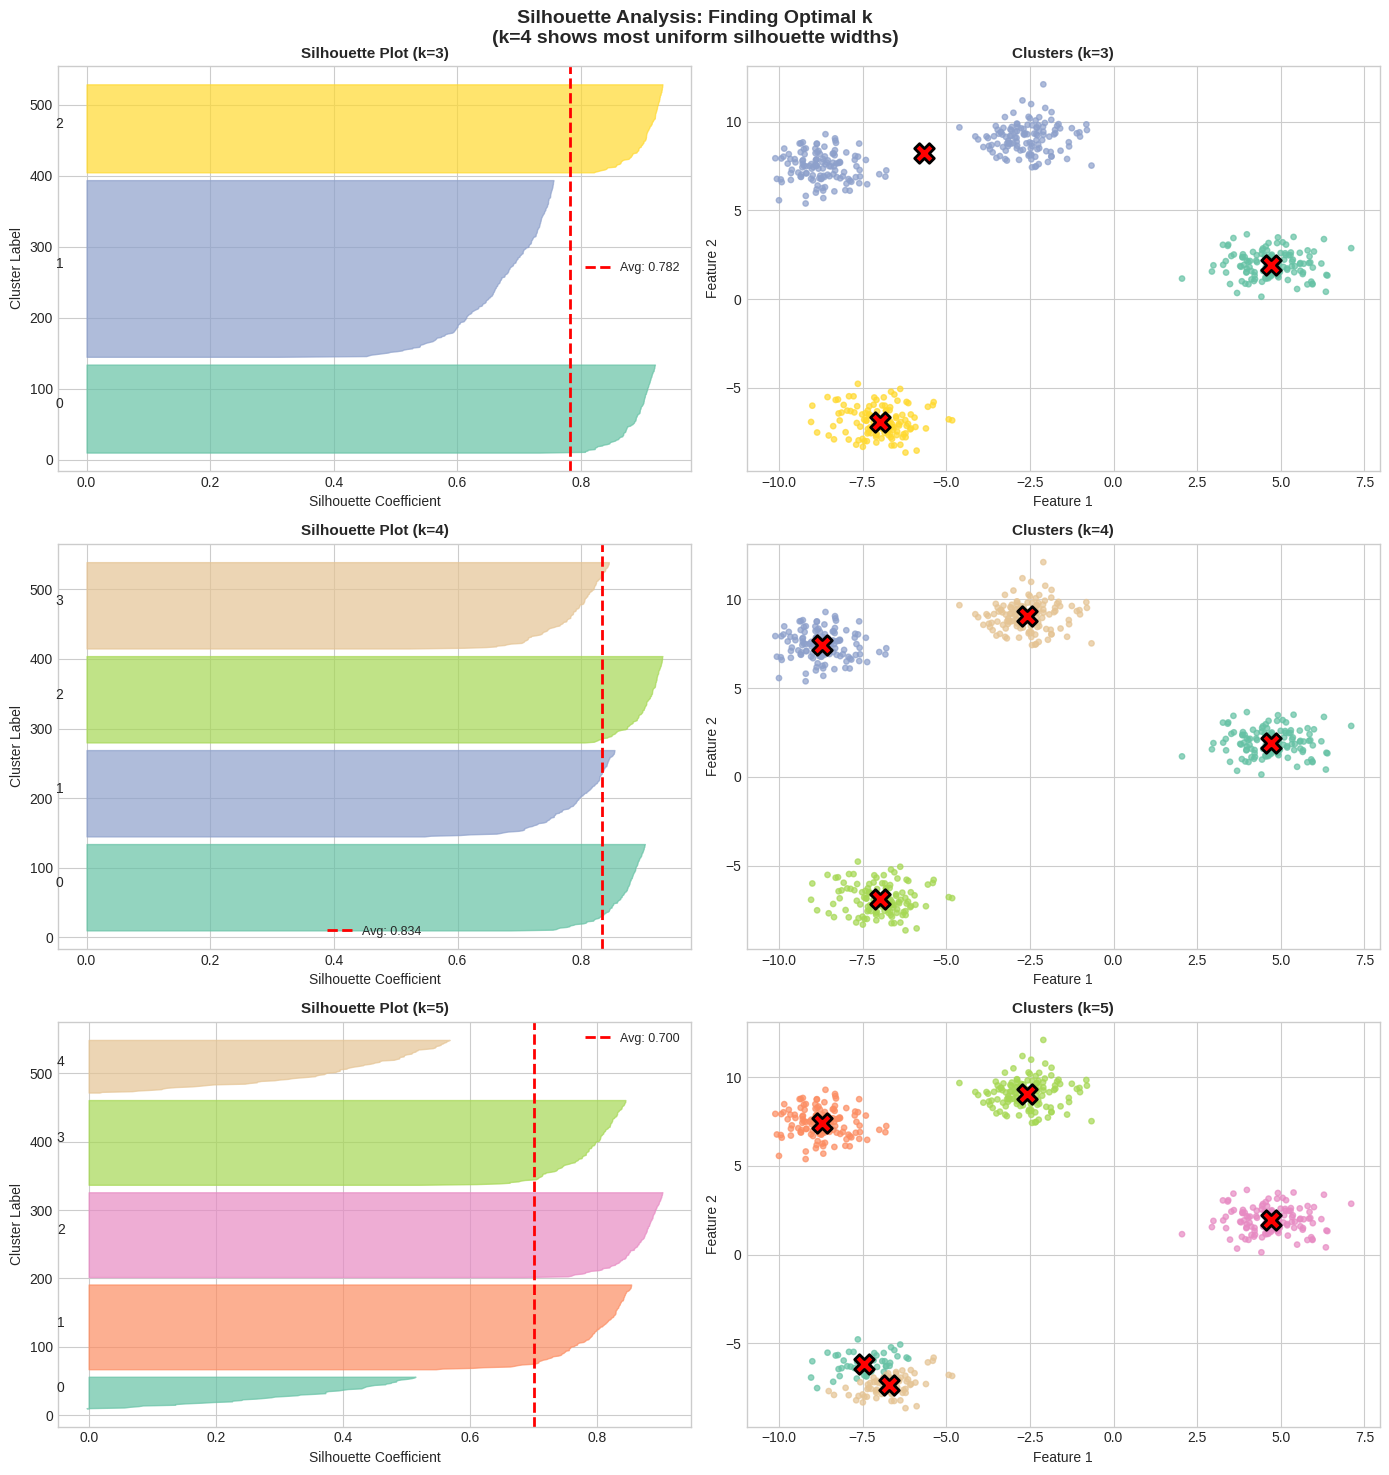

In [0]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

def plot_silhouette_analysis(X, n_clusters, ax1, ax2):
    """Create silhouette plot and corresponding cluster visualization."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[labels == i]
        ith_cluster_values.sort()
        
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.Set2(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10)
        y_lower = y_upper + 10
    
    ax1.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=2,
               label=f'Avg: {silhouette_avg:.3f}')
    ax1.set_xlabel('Silhouette Coefficient', fontsize=10)
    ax1.set_ylabel('Cluster Label', fontsize=10)
    ax1.set_title(f'Silhouette Plot (k={n_clusters})', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    
    # Cluster visualization
    colors = cm.Set2(labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.7)
    centers = kmeans.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='X', c='red', s=200, 
               edgecolors='black', linewidths=2, zorder=5)
    ax2.set_title(f'Clusters (k={n_clusters})', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Feature 1')
    ax2.set_ylabel('Feature 2')

# Silhouette analysis for different k values
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for idx, k in enumerate([3, 4, 5]):
    plot_silhouette_analysis(X_blobs, k, axes[idx, 0], axes[idx, 1])

plt.suptitle('Silhouette Analysis: Finding Optimal k\n(k=4 shows most uniform silhouette widths)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Algorithm Comparison & Selection Guide

### Decision Framework: When to Use Which Algorithm

| Scenario | Recommended Algorithm | Why |
| --- | --- | --- |
| Large dataset, spherical clusters | **K-Means** | Fast, scalable, works well |
| Unknown number of clusters | **DBSCAN** or **Mean Shift** | Automatically determines k |
| Non-convex shapes | **DBSCAN** or **Spectral** | Not limited to spherical assumptions |
| Hierarchical structure needed | **Agglomerative** | Produces dendrogram |
| Soft assignments / probabilities | **GMM** | Gives membership probabilities |
| Clusters of varying density | **OPTICS** or **HDBSCAN** | Handles density variation |
| High-dimensional data | **K-Means** or **GMM** | More robust in high dimensions |
| Small dataset, need interpretability | **Hierarchical** | Visual dendrogram |
| Outlier detection needed | **DBSCAN** | Labels noise points |
| Graph/network data | **Spectral** | Works on similarity graphs |

### Computational Complexity Summary

| Algorithm | Time Complexity | Space Complexity | Scalability |
| --- | --- | --- | --- |
| K-Means | $$O(nkdi)$$ | $$O(nd + kd)$$ | Excellent |
| Hierarchical | $$O(n^2 \log n)$$ | $$O(n^2)$$ | Poor |
| DBSCAN | $$O(n \log n)$$ | $$O(n)$$ | Good |
| GMM | $$O(nk d^2 i)$$ | $$O(nk + kd^2)$$ | Moderate |
| Mean Shift | $$O(n^2 T)$$ | $$O(n)$$ | Poor |
| Spectral | $$O(n^3)$$ | $$O(n^2)$$ | Poor |

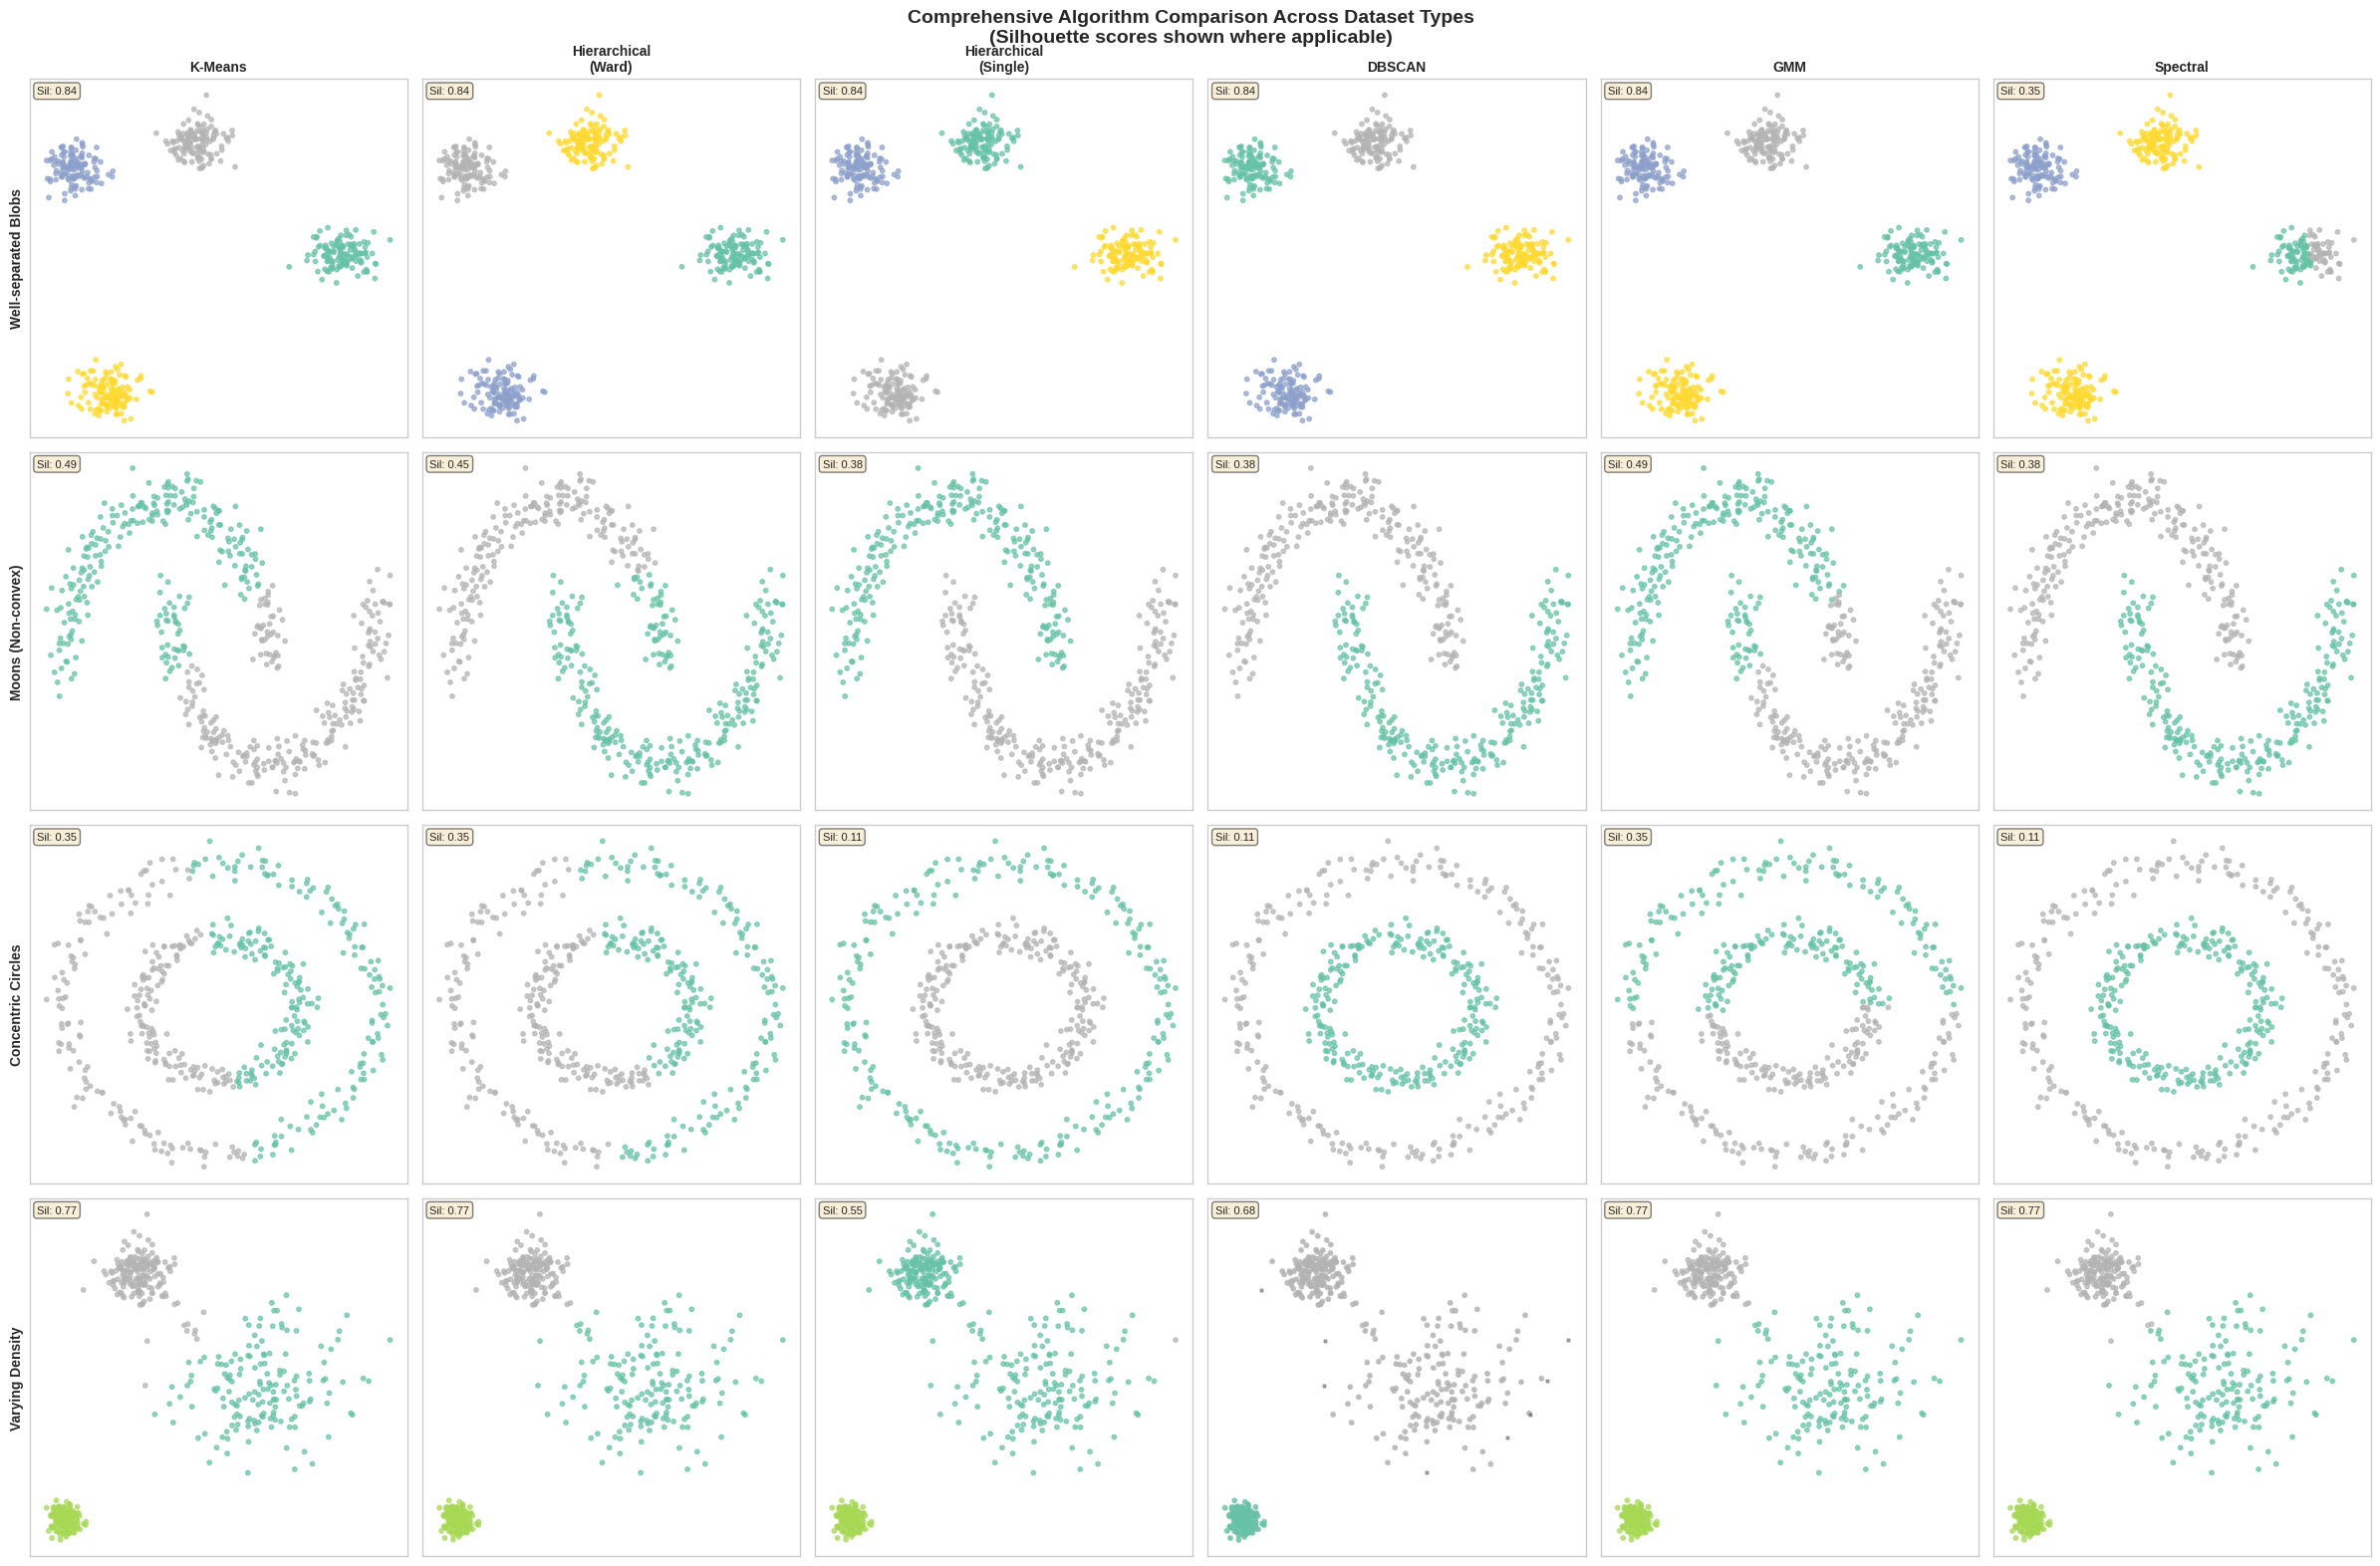

In [0]:
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN, 
                              MeanShift, SpectralClustering)
from sklearn.mixture import GaussianMixture
import time

# Comprehensive comparison across all datasets
datasets_compare = [
    (X_blobs, y_blobs, 4, 'Well-separated Blobs'),
    (X_moons, y_moons, 2, 'Moons (Non-convex)'),
    (X_circles, y_circles, 2, 'Concentric Circles'),
    (X_varied, y_varied, 3, 'Varying Density'),
]

algo_configs = [
    ('K-Means', lambda k: KMeans(n_clusters=k, random_state=42, n_init=10)),
    ('Hierarchical\n(Ward)', lambda k: AgglomerativeClustering(n_clusters=k, linkage='ward')),
    ('Hierarchical\n(Single)', lambda k: AgglomerativeClustering(n_clusters=k, linkage='single')),
    ('DBSCAN', lambda k: DBSCAN(eps=0.3, min_samples=5)),
    ('GMM', lambda k: GaussianMixture(n_components=k, random_state=42)),
    ('Spectral', lambda k: SpectralClustering(n_clusters=k, affinity='nearest_neighbors', 
                                               n_neighbors=10, random_state=42)),
]

fig, axes = plt.subplots(4, 6, figsize=(24, 16))

for row, (X, y_true, k, dataset_name) in enumerate(datasets_compare):
    # Scale data for consistent behavior
    X_scaled = StandardScaler().fit_transform(X)
    
    for col, (algo_name, algo_factory) in enumerate(algo_configs):
        ax = axes[row, col]
        
        try:
            algo = algo_factory(k)
            labels = algo.fit_predict(X_scaled)
            
            # Handle noise for DBSCAN
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            
            for label in unique_labels:
                mask = labels == label
                if label == -1:
                    ax.scatter(X[:, 0], X[:, 1], c='gray', s=5, alpha=0.3, marker='x')
                    break
            
            # Color non-noise points
            non_noise = labels != -1
            if non_noise.any():
                ax.scatter(X[non_noise, 0], X[non_noise, 1], 
                          c=labels[non_noise], cmap='Set2', s=10, alpha=0.7)
            if (~non_noise).any():
                ax.scatter(X[~non_noise, 0], X[~non_noise, 1], 
                          c='black', s=5, alpha=0.3, marker='x')
            
            # Compute silhouette if possible
            if n_clusters > 1 and n_clusters < len(X):
                valid = labels != -1
                if valid.sum() > n_clusters:
                    sil = silhouette_score(X_scaled[valid], labels[valid])
                    ax.text(0.02, 0.98, f'Sil: {sil:.2f}', transform=ax.transAxes,
                           fontsize=8, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        except Exception as e:
            ax.text(0.5, 0.5, 'Error', transform=ax.transAxes, ha='center')
        
        if row == 0:
            ax.set_title(algo_name, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(dataset_name, fontsize=10, fontweight='bold')
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Comprehensive Algorithm Comparison Across Dataset Types\n'
             '(Silhouette scores shown where applicable)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Real-World Application: Customer Segmentation

Let's apply clustering to a realistic customer segmentation problem — one of the most common business applications of clustering.

In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Simulate realistic customer data
np.random.seed(42)
n_customers = 1000

# Create customer segments with realistic patterns
# Segment 1: High-value frequent buyers
seg1 = np.column_stack([
    np.random.normal(150, 30, 250),    # avg_order_value
    np.random.normal(25, 5, 250),       # orders_per_year
    np.random.normal(8, 2, 250),        # years_as_customer
    np.random.normal(4500, 800, 250),   # annual_spend
    np.random.normal(85, 10, 250),      # satisfaction_score
])

# Segment 2: Budget-conscious regulars  
seg2 = np.column_stack([
    np.random.normal(40, 15, 300),      # avg_order_value
    np.random.normal(15, 4, 300),       # orders_per_year
    np.random.normal(4, 1.5, 300),      # years_as_customer
    np.random.normal(700, 200, 300),    # annual_spend
    np.random.normal(70, 12, 300),      # satisfaction_score
])

# Segment 3: Occasional big spenders
seg3 = np.column_stack([
    np.random.normal(250, 60, 200),     # avg_order_value
    np.random.normal(4, 2, 200),        # orders_per_year
    np.random.normal(3, 1, 200),        # years_as_customer
    np.random.normal(1200, 400, 200),   # annual_spend
    np.random.normal(75, 15, 200),      # satisfaction_score
])

# Segment 4: New/Inactive customers
seg4 = np.column_stack([
    np.random.normal(60, 25, 250),      # avg_order_value
    np.random.normal(2, 1.5, 250),      # orders_per_year
    np.random.normal(1, 0.5, 250),      # years_as_customer
    np.random.normal(150, 80, 250),     # annual_spend
    np.random.normal(55, 18, 250),      # satisfaction_score
])

X_customers = np.vstack([seg1, seg2, seg3, seg4])
X_customers = np.abs(X_customers)  # Ensure positive values

feature_names = ['Avg Order Value ($)', 'Orders/Year', 'Tenure (Years)', 
                 'Annual Spend ($)', 'Satisfaction Score']

df_customers = pd.DataFrame(X_customers, columns=feature_names)

print("Customer Dataset Summary:")
print(f"Shape: {df_customers.shape}")
print(f"\nFeature Statistics:")
display(df_customers.describe().round(2))

Customer Dataset Summary:
Shape: (1000, 5)

Feature Statistics:


Avg Order Value ($),Orders/Year,Tenure (Years),Annual Spend ($),Satisfaction Score
1000.0,1000.0,1000.0,1000.0,1000.0
113.46,12.09,4.01,1640.88,71.62
85.49,9.76,2.85,1802.9,18.19
0.24,0.05,0.0,4.31,2.18
44.82,2.86,1.52,286.45,60.29
77.58,11.41,3.6,813.33,73.8
165.67,19.72,5.69,2221.95,84.08
485.57,40.39,13.15,6605.91,123.65


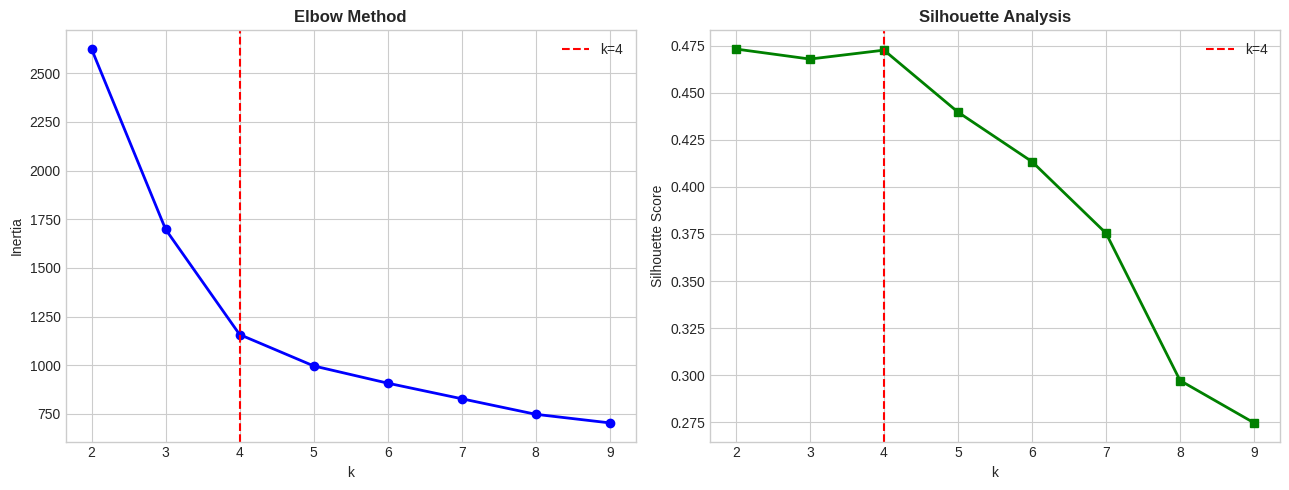


CUSTOMER SEGMENT PROFILES


Avg Order Value ($),Orders/Year,Tenure (Years),Annual Spend ($),Satisfaction Score,Count
41.9,14.8,4.0,694.8,72.5,298
58.9,2.5,1.1,192.8,53.4,260
149.9,25.1,7.9,4604.8,86.1,250
251.0,3.9,3.0,1211.0,76.0,192


In [0]:
# Step 1: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customers)

# Step 2: Find optimal k using elbow + silhouette
k_range = range(2, 10)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(k_range, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.axvline(x=4, color='red', linestyle='--', label='k=4')
ax1.legend()

ax2.plot(k_range, sil_scores, 'gs-', linewidth=2)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis', fontweight='bold')
ax2.axvline(x=4, color='red', linestyle='--', label='k=4')
ax2.legend()
plt.tight_layout()
plt.show()

# Step 3: Fit final model with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_customers['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Step 4: Analyze segments
print("\n" + "=" * 70)
print("CUSTOMER SEGMENT PROFILES")
print("=" * 70)
segment_profiles = df_customers.groupby('Cluster')[feature_names].mean().round(1)
segment_profiles['Count'] = df_customers.groupby('Cluster').size()
display(segment_profiles)

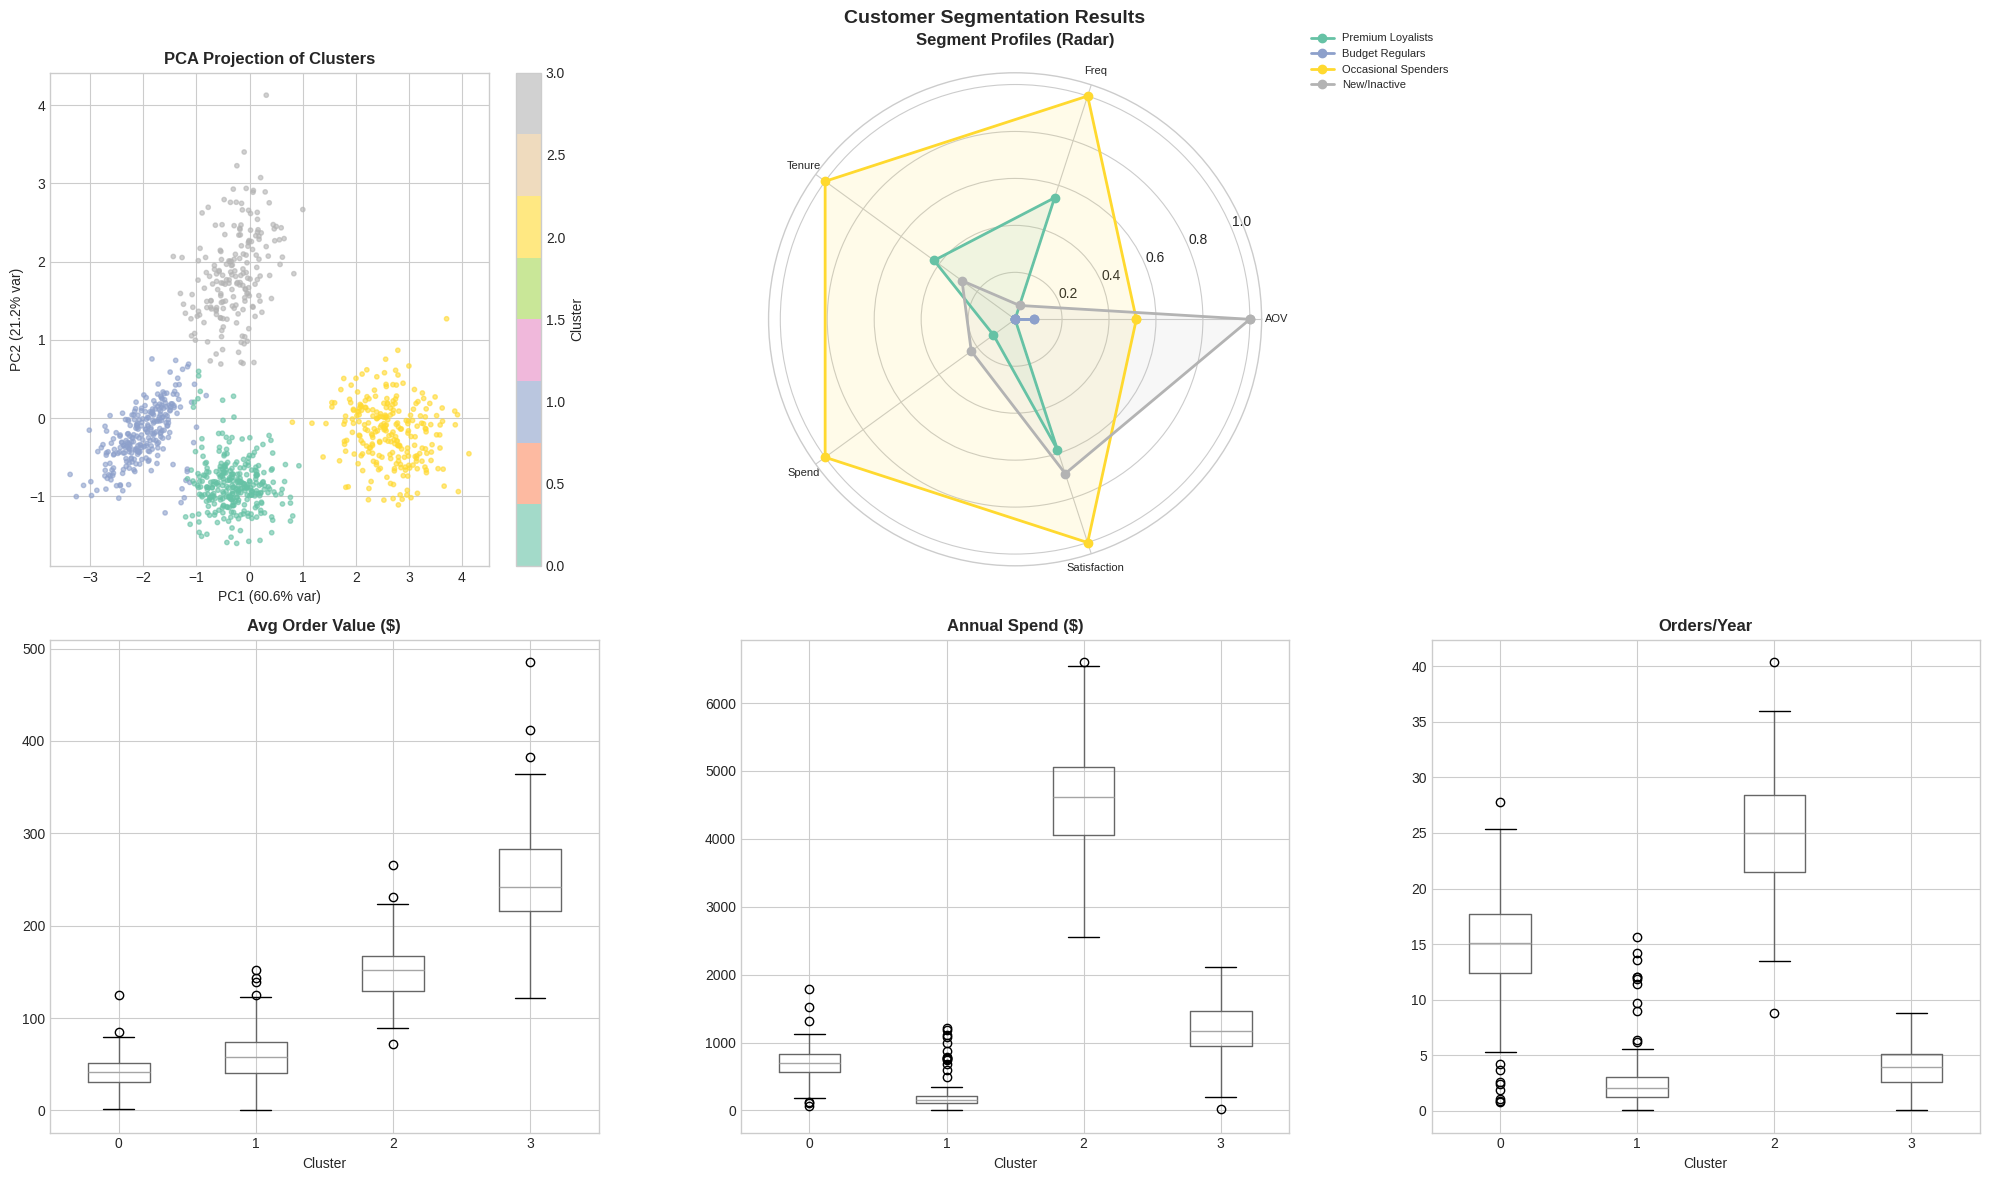


BUSINESS RECOMMENDATIONS BY SEGMENT
  Cluster 0: PREMIUM LOYALISTS: VIP program, exclusive previews, personalized service
  Cluster 1: BUDGET REGULARS: Volume discounts, loyalty rewards, bundle offers
  Cluster 2: OCCASIONAL SPENDERS: Targeted re-engagement, premium product highlights
  Cluster 3: NEW/INACTIVE: Onboarding campaigns, welcome discounts, win-back emails


In [0]:
# Comprehensive segment visualization
fig = plt.figure(figsize=(20, 12))

# 1. PCA visualization
ax1 = fig.add_subplot(2, 3, 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df_customers['Cluster'], 
                      cmap='Set2', s=10, alpha=0.6)
ax1.set_title('PCA Projection of Clusters', fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# 2. Radar/Spider chart for segment profiles
ax2 = fig.add_subplot(2, 3, 2, projection='polar')

# Normalize features to [0, 1] for radar chart
from sklearn.preprocessing import MinMaxScaler
profiles_normalized = MinMaxScaler().fit_transform(segment_profiles[feature_names].values)

angles = np.linspace(0, 2 * np.pi, len(feature_names), endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

colors_radar = plt.cm.Set2(np.linspace(0, 1, 4))
segment_names = ['Premium Loyalists', 'Budget Regulars', 'Occasional Spenders', 'New/Inactive']

for i in range(4):
    values = profiles_normalized[i].tolist()
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i], label=segment_names[i])
    ax2.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(['AOV', 'Freq', 'Tenure', 'Spend', 'Satisfaction'], fontsize=8)
ax2.set_title('Segment Profiles (Radar)', fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)

# 3. Box plots for key features
for idx, feature in enumerate(['Avg Order Value ($)', 'Annual Spend ($)', 'Orders/Year']):
    ax = fig.add_subplot(2, 3, idx + 4)
    df_customers.boxplot(column=feature, by='Cluster', ax=ax)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Cluster')
    plt.suptitle('')  # Remove auto-title

plt.suptitle('Customer Segmentation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Business recommendations
print("\n" + "=" * 70)
print("BUSINESS RECOMMENDATIONS BY SEGMENT")
print("=" * 70)
recommendations = {
    0: "PREMIUM LOYALISTS: VIP program, exclusive previews, personalized service",
    1: "BUDGET REGULARS: Volume discounts, loyalty rewards, bundle offers",
    2: "OCCASIONAL SPENDERS: Targeted re-engagement, premium product highlights",
    3: "NEW/INACTIVE: Onboarding campaigns, welcome discounts, win-back emails"
}
for cluster, rec in recommendations.items():
    print(f"  Cluster {cluster}: {rec}")

---
## 11. Advanced Topics & Best Practices

### Data Preprocessing for Clustering
1. **Feature Scaling:** ALWAYS standardize/normalize features (Z-score or Min-Max)
2. **Dimensionality Reduction:** Use PCA or t-SNE for visualization; PCA for noise reduction
3. **Feature Selection:** Remove highly correlated features; use domain knowledge
4. **Handling Outliers:** Consider removal or use robust algorithms (DBSCAN, Median-based)
5. **Handling Categorical Data:** Use K-Modes, Gower distance, or one-hot encoding

### Common Pitfalls
- **Curse of Dimensionality:** Distance metrics become less meaningful in high dimensions
- **Ignoring Feature Scales:** Features with larger ranges dominate distance calculations
- **Choosing Wrong k:** Always validate with multiple methods (elbow, silhouette, domain knowledge)
- **Ignoring Data Distribution:** K-Means assumes spherical; real data is often not
- **Not Validating Results:** Always check cluster stability (bootstrap, multiple runs)

### Cluster Stability Assessment
Techniques to validate whether clusters are "real":
- **Bootstrap resampling:** Run clustering on multiple bootstrap samples
- **Cross-validation:** Split data, cluster each half, measure agreement
- **Perturbation:** Add noise and check if clusters persist
- **Consensus clustering:** Aggregate results from multiple runs/algorithms

### Scaling to Big Data
| Algorithm | Big Data Variant | Available In |
| --- | --- | --- |
| K-Means | Mini-Batch K-Means | sklearn, Spark MLlib |
| Hierarchical | BIRCH | sklearn |
| DBSCAN | HDBSCAN | hdbscan library |
| All | Sampling + clustering | Custom |

### Key Takeaways
1. **No single algorithm wins everywhere** — match algorithm to data characteristics
2. **Preprocessing is critical** — scaling and dimensionality reduction often matter more than algorithm choice
3. **Validate results** — use multiple metrics, domain expertise, and stability checks
4. **Clustering is exploratory** — it generates hypotheses, not conclusions
5. **Business context matters** — a "good" clustering is one that's actionable

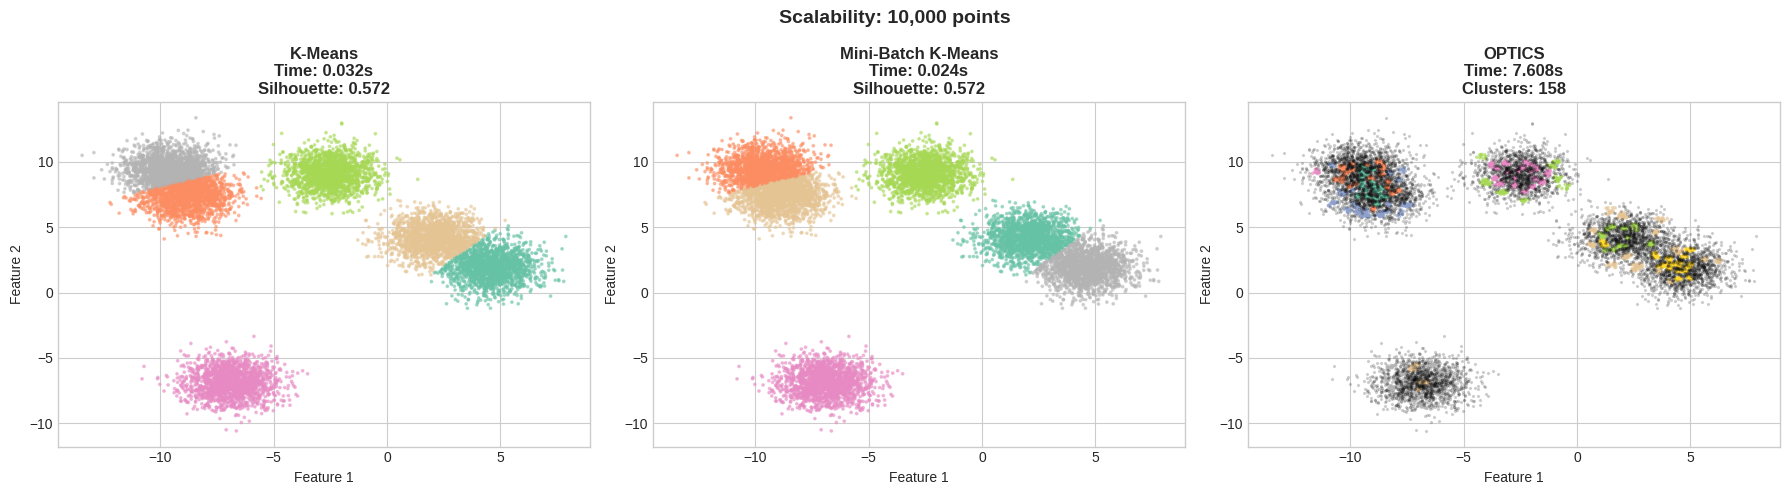


Timing Comparison (10,000 samples):
  K-Means                   0.0323 seconds
  Mini-Batch K-Means        0.0242 seconds
  OPTICS                    7.6078 seconds

Mini-Batch speedup: 1.3x faster


In [0]:
from sklearn.cluster import MiniBatchKMeans, OPTICS
import time

# Generate larger dataset for scalability comparison
X_large, _ = make_blobs(n_samples=10000, centers=6, cluster_std=1.0, random_state=42)
X_large_scaled = StandardScaler().fit_transform(X_large)

# Timing comparison: K-Means vs Mini-Batch K-Means
results_timing = {}

# Standard K-Means
start = time.time()
km_standard = KMeans(n_clusters=6, random_state=42, n_init=10)
km_standard.fit(X_large_scaled)
results_timing['K-Means'] = time.time() - start

# Mini-Batch K-Means
start = time.time()
km_mini = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=256, n_init=10)
km_mini.fit(X_large_scaled)
results_timing['Mini-Batch K-Means'] = time.time() - start

# OPTICS (density-based, handles varying densities)
start = time.time()
optics = OPTICS(min_samples=10, xi=0.05)
optics.fit(X_large_scaled)
results_timing['OPTICS'] = time.time() - start

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means result
axes[0].scatter(X_large[:, 0], X_large[:, 1], c=km_standard.labels_, cmap='Set2', s=3, alpha=0.5)
axes[0].set_title(f'K-Means\nTime: {results_timing["K-Means"]:.3f}s\n'
                  f'Silhouette: {silhouette_score(X_large_scaled, km_standard.labels_):.3f}',
                  fontweight='bold')

# Mini-Batch result
axes[1].scatter(X_large[:, 0], X_large[:, 1], c=km_mini.labels_, cmap='Set2', s=3, alpha=0.5)
axes[1].set_title(f'Mini-Batch K-Means\nTime: {results_timing["Mini-Batch K-Means"]:.3f}s\n'
                  f'Silhouette: {silhouette_score(X_large_scaled, km_mini.labels_):.3f}',
                  fontweight='bold')

# OPTICS result
valid_optics = optics.labels_ != -1
if valid_optics.any():
    axes[2].scatter(X_large[valid_optics, 0], X_large[valid_optics, 1], 
                    c=optics.labels_[valid_optics], cmap='Set2', s=3, alpha=0.5)
    axes[2].scatter(X_large[~valid_optics, 0], X_large[~valid_optics, 1], 
                    c='black', s=2, alpha=0.2, marker='x')
axes[2].set_title(f'OPTICS\nTime: {results_timing["OPTICS"]:.3f}s\n'
                  f'Clusters: {len(set(optics.labels_)) - 1}',
                  fontweight='bold')

for ax in axes:
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Scalability: 10,000 points', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTiming Comparison (10,000 samples):")
for algo, t in results_timing.items():
    print(f"  {algo:<25} {t:.4f} seconds")
print(f"\nMini-Batch speedup: {results_timing['K-Means']/results_timing['Mini-Batch K-Means']:.1f}x faster")

---
## 12. References & Further Reading

### Foundational Papers
1. **K-Means:** Lloyd, S. (1982). "Least squares quantization in PCM." *IEEE Trans. Info. Theory*
2. **K-Means++:** Arthur, D. & Vassilvitskii, S. (2007). "k-means++: The Advantages of Careful Seeding." *SODA*
3. **DBSCAN:** Ester, M. et al. (1996). "A Density-Based Algorithm for Discovering Clusters." *KDD*
4. **EM/GMM:** Dempster, A. et al. (1977). "Maximum Likelihood from Incomplete Data via the EM Algorithm." *JRSS*
5. **Spectral Clustering:** Ng, A. et al. (2001). "On Spectral Clustering: Analysis and an Algorithm." *NIPS*
6. **Mean Shift:** Comaniciu, D. & Meer, P. (2002). "Mean Shift: A Robust Approach." *IEEE TPAMI*
7. **HDBSCAN:** Campello, R. et al. (2013). "Density-Based Clustering Based on Hierarchical Density Estimates." *PAKDD*

### Recommended Books
- *Pattern Recognition and Machine Learning* — Christopher Bishop (Ch. 9: Mixture Models and EM)
- *The Elements of Statistical Learning* — Hastie, Tibshirani, Friedman (Ch. 14: Unsupervised Learning)
- *Machine Learning: A Probabilistic Perspective* — Kevin Murphy (Ch. 25: Clustering)

### Python Libraries Used
- `scikit-learn`: Primary ML library with most algorithms
- `scipy.cluster.hierarchy`: Hierarchical clustering & dendrograms
- `hdbscan`: Hierarchical DBSCAN (not covered here, but recommended for real-world use)
- `matplotlib` / `seaborn`: Visualization